# Bibliotecas

In [1]:
import os

import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

# from sklearn.preprocessing import StandardScaler

# from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

# from factor_analyzer.factor_analyzer import calculate_kmo

from factor_analyzer import FactorAnalyzer

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

import umap.umap_ as umap

from statsmodels.multivariate.manova import MANOVA

# from scipy.stats import chi2
from scipy.stats import chi2 as chi2_dist

/home/erick/Entorno/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATH = r'https://raw.githubusercontent.com/Wsm-erick/Diplomado/refs/heads/main/Modulo-III/Datasets'

# Ejercicio 1

## EDA

In [3]:
encuesta = pd.read_csv(os.path.join(PATH, 'data_practica_encuesta.csv'))

In [4]:
encuesta.shape

(25976, 14)

In [5]:
encuesta.head()

,Id,Servicio wifi a bordo,Hora de salida/llegada conveniente,Facilidad de reserva en línea,Ubicación de la puerta,Alimentos y bebidas,Embarque en línea,Comodidad del asiento,Entretenimiento a bordo,Servicio a bordo,Servicio de sala de piernas,Manejo de equipaje,Servicio de facturación,Limpieza
0,19556,5,4,3,4,3,4,3,5,5,5,5,2,5
1,90035,1,1,3,1,5,4,5,4,4,4,4,3,5
2,12360,2,0,2,4,2,2,2,2,4,1,3,2,2
3,77959,0,0,0,2,3,4,4,1,1,1,1,3,4
4,36875,2,3,4,3,4,1,2,2,2,2,2,4,4


In [6]:
encuesta.columns.tolist()

['Id',
 'Servicio wifi a bordo',
 'Hora de salida/llegada conveniente',
 'Facilidad de reserva en línea',
 'Ubicación de la puerta',
 'Alimentos y bebidas',
 'Embarque en línea',
 'Comodidad del asiento',
 'Entretenimiento a bordo',
 'Servicio a bordo',
 'Servicio de sala de piernas',
 'Manejo de equipaje',
 'Servicio de facturación',
 'Limpieza']

In [7]:
encuesta.loc[:,'Servicio wifi a bordo':].describe().T

,count,mean,std,min,25%,50%,75%,max
Servicio wifi a bordo,25976.0,2.724746,1.335384,0.0,2.0,3.0,4.0,5.0
Hora de salida/llegada conveniente,25976.0,3.046812,1.533371,0.0,2.0,3.0,4.0,5.0
Facilidad de reserva en línea,25976.0,2.756775,1.412951,0.0,2.0,3.0,4.0,5.0
Ubicación de la puerta,25976.0,2.977094,1.282133,1.0,2.0,3.0,4.0,5.0
Alimentos y bebidas,25976.0,3.215353,1.331506,0.0,2.0,3.0,4.0,5.0
Embarque en línea,25976.0,3.261665,1.355536,0.0,2.0,4.0,4.0,5.0
Comodidad del asiento,25976.0,3.449222,1.320090,1.0,2.0,4.0,5.0,5.0
Entretenimiento a bordo,25976.0,3.357753,1.338299,0.0,2.0,4.0,4.0,5.0
Servicio a bordo,25976.0,3.385664,1.282088,0.0,2.0,4.0,4.0,5.0
Servicio de sala de piernas,25976.0,3.350169,1.318862,0.0,2.0,4.0,4.0,5.0


In [8]:
N = encuesta.shape[0]

print('Proporción de missings...', end='\n\n')

for col in encuesta.columns:
    n = encuesta.loc[:, col].isna().sum()
    print(f'{col} -', n/N)

Proporción de missings...

Id - 0.0
Servicio wifi a bordo - 0.0
Hora de salida/llegada conveniente - 0.0
Facilidad de reserva en línea - 0.0
Ubicación de la puerta - 0.0
Alimentos y bebidas - 0.0
Embarque en línea - 0.0
Comodidad del asiento - 0.0
Entretenimiento a bordo - 0.0
Servicio a bordo - 0.0
Servicio de sala de piernas - 0.0
Manejo de equipaje - 0.0
Servicio de facturación - 0.0
Limpieza - 0.0


No hay valores vacíos.

In [9]:
scaler =  StandardScaler()
columns = encuesta.columns
encuesta_tr = scaler.fit_transform(encuesta)
encuesta_tr = pd.DataFrame(data=encuesta_tr, columns=columns)
encuesta_tr.head(10)

,Id,Servicio wifi a bordo,Hora de salida/llegada conveniente,Facilidad de reserva en línea,Ubicación de la puerta,Alimentos y bebidas,Embarque en línea,Comodidad del asiento,Entretenimiento a bordo,Servicio a bordo,Servicio de sala de piernas,Manejo de equipaje,Servicio de facturación,Limpieza
0,-1.208420,1.703853,0.621641,0.172143,0.797831,-0.161739,0.544692,-0.340303,1.227138,1.259170,1.250974,1.161716,-1.035348,1.298998
1,0.665483,-1.291598,-1.334871,0.172143,-1.542065,1.340348,0.544692,1.174774,0.479907,0.479178,0.492730,0.311739,-0.247517,1.298998
2,-1.399748,-0.542735,-1.987042,-0.535609,0.797831,-0.912783,-0.930768,-1.097842,-1.014556,0.479178,-1.782001,-0.538238,-1.035348,-0.974927
3,0.344405,-2.040460,-1.987042,-1.951114,-0.762100,-0.161739,0.544692,0.417235,-1.761787,-1.860800,-1.782001,-2.238193,-0.247517,0.541023
4,-0.747941,-0.542735,-0.030530,0.879895,0.017866,0.589304,-1.668498,-1.097842,-1.014556,-1.080807,-1.023758,-1.388216,0.540315,0.541023
5,-0.686735,0.206128,-0.030530,0.172143,0.017866,1.340348,1.282422,-0.340303,1.227138,0.479178,-0.265514,-2.238193,-1.823179,1.298998
6,0.383596,1.703853,1.273812,1.587647,1.577797,-0.161739,1.282422,1.174774,1.227138,1.259170,1.250974,1.161716,0.540315,-0.216952
7,0.858273,-0.542735,-0.682700,-0.535609,-0.762100,0.589304,0.544692,1.174774,0.479907,0.479178,0.492730,0.311739,1.328146,-0.216952
8,-0.996992,1.703853,-0.682700,-0.535609,-0.762100,1.340348,1.282422,1.174774,1.227138,-1.080807,-1.023758,1.161716,-0.247517,1.298998
9,-0.067099,-0.542735,-0.682700,-0.535609,-0.762100,-0.161739,0.544692,0.417235,0.479907,0.479178,0.492730,0.311739,1.328146,0.541023


### Prueba de esfericidad de Barlett

In [10]:
chi2, p = calculate_bartlett_sphericity(encuesta_tr)
print("Esfericidad de Bartlett")
print("Valor de Chi : ", chi2)
print("P - value : ", p)

Esfericidad de Bartlett
Valor de Chi :  134048.10599559
P - value :  0.0


> $H_{0}$ : La matriz de correlaciones es la identidad, es decir, no hay correlación entre variables. <br>
> $H_{1}$ : La matriz si tiene correlación significativa.

* *Si $\,p-value < 0.05$ entonces rechaza $H_{0}$ (hay correlación entre variables)*
* *Si $\,p-value ≥ 0.05$ entonces no rechaza $H_{0}$ (variables independientes)*

La prueba de esfericidad de Bartlett fue significativa (p < 0.05), lo que indica que la matriz de correlaciones difiere significativamente de la matriz identidad, justificando la aplicación de técnicas de reducción de dimensionalidad como el análisis de componentes principales.

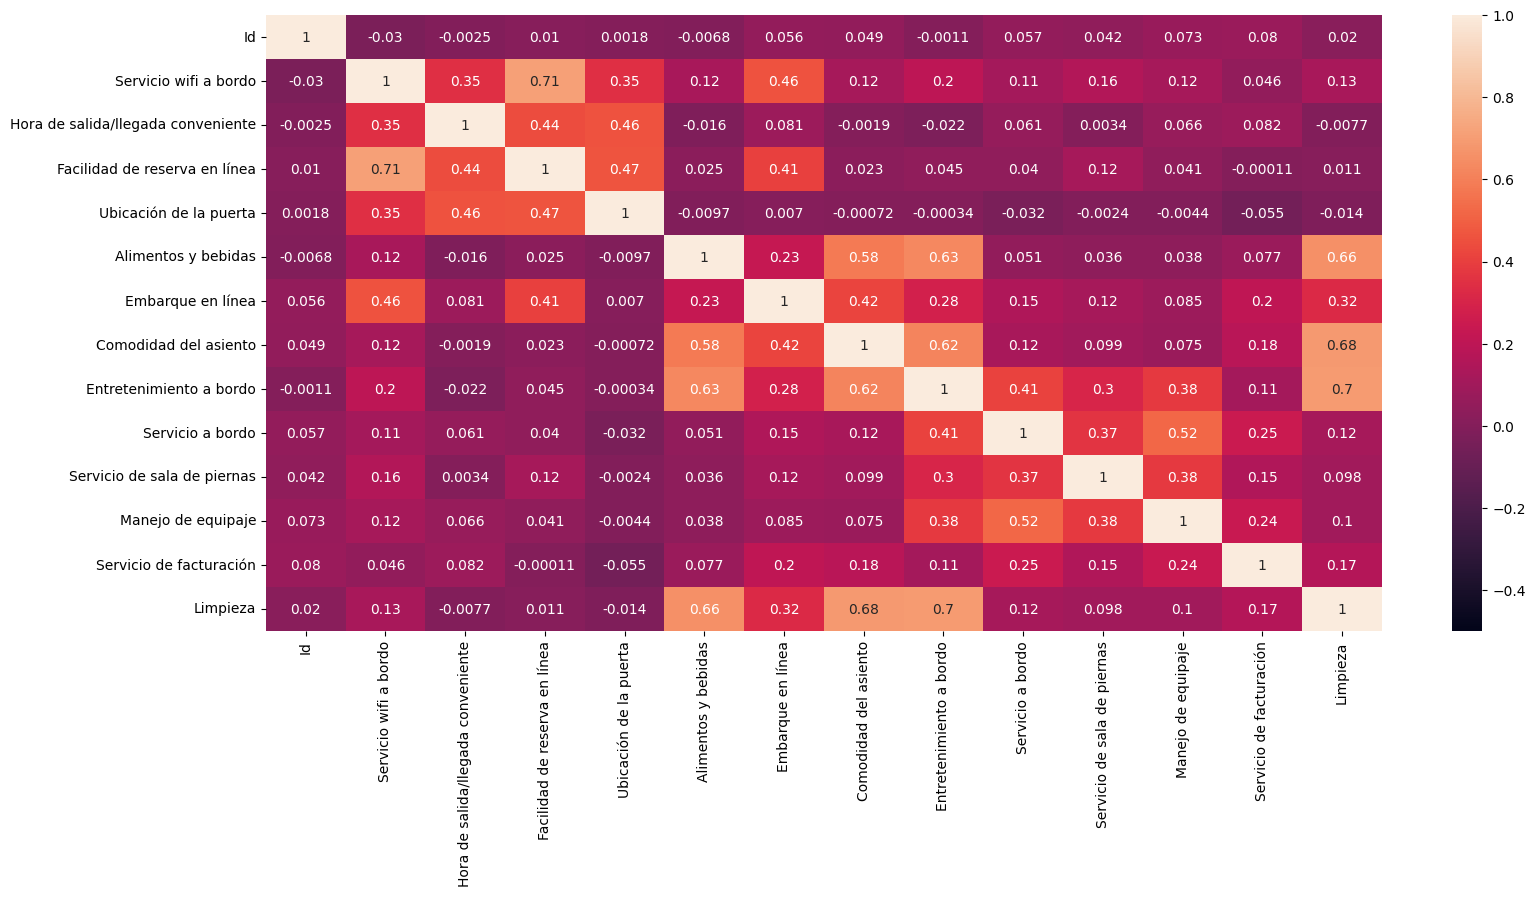

In [11]:
plt.figure(figsize=(18,8))
sns.heatmap(encuesta_tr.corr(), annot=True, vmax=1, vmin=-0.5)
plt.show()

De la matriz de correlación podemos deducir que existe una buena relación entre las variables, vamos aplicar la prueba KMO para reforzar el enunciado.

### Prueba KMO

In [12]:
kmo_all, kmo_model = calculate_kmo(encuesta_tr)
print("KMO Test Statisitc:", "{:.6f}".format(kmo_model))

KMO Test Statisitc: 0.759652


Estructura factorial adecuada

In [13]:
kmo_all.__len__()

14

In [14]:
encuesta_tr.shape[1]

14

In [15]:
pd.Series(kmo_all.tolist())

0     0.528672
1     0.742391
2     0.752037
3     0.687548
4     0.704245
5     0.837731
6     0.731142
7     0.825686
8     0.745286
9     0.717652
10    0.825903
11    0.726719
12    0.661351
13    0.819793
dtype: float64

* El índice Kaiser-Meyer-Olkin (KMO) obtuvo un valor de 0.76, lo que indica una adecuación muestral buena para la aplicación del análisis factorial. Asimismo, la prueba de esfericidad de Bartlett fue estadísticamente significativa (χ² = 134,048; p < 0.001), lo que evidencia que la matriz de correlaciones difiere significativamente de la matriz identidad. En conjunto, estos resultados justifican la aplicación del análisis factorial.

### No. de factores

In [16]:
fa = FactorAnalyzer(rotation = None, impute = "drop", n_factors=encuesta_tr.shape[1])

In [17]:
fa.fit(encuesta_tr)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,14
,rotation,None
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'drop'
,svd_method,'randomized'
,rotation_kwargs,{}


In [18]:
ev, _ = fa.get_eigenvalues()

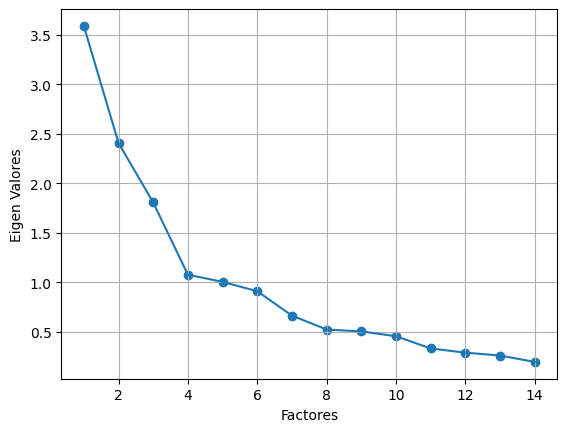

In [19]:
plt.scatter(range(1, encuesta_tr.shape[1]+1), ev)
plt.plot(range(1, encuesta_tr.shape[1]+1), ev)
plt.xlabel('Factores')
plt.ylabel('Eigen Valores')
plt.grid()

In [20]:
pd.Series(ev[ev > 1].tolist())

0    3.590307
1    2.406963
2    1.805530
3    1.075359
4    1.003151
dtype: float64

El número de componentes óptimo para nuestra muestra es de 5 ya que después de 5 componentes la varianza explicada es menor a una variable observada.

In [21]:
n_factors = ev[ev > 1].__len__()
n_factors

5

### Interpretar los Factores

In [22]:
#https://www.ibm.com/docs/es/spss-statistics/SaaS?topic=analysis-factor-rotation
#MÉTODOS DE ROTACION
fa = FactorAnalyzer(n_factors=n_factors,rotation=None)
fa.fit(encuesta_tr)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,5
,rotation,None
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [23]:
fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(encuesta_tr)

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,n_factors,5
,rotation,'varimax'
,method,'minres'
,use_smc,True
,is_corr_matrix,False
,bounds,"(0.005, ...)"
,impute,'median'
,svd_method,'randomized'
,rotation_kwargs,{}


In [24]:
pd.DataFrame(fa.get_eigenvalues()[0],columns=['EigenValues'])

,EigenValues
0,3.590307
1,2.406963
2,1.805530
3,1.075359
4,1.003151
5,0.908686
6,0.662304
7,0.521551
8,0.501943
9,0.454025


### Cargas

In [25]:
cm = sns.light_palette("blue", as_cmap=True)

In [26]:
pd.Series(encuesta_tr.columns.tolist())

0                                     Id
1                  Servicio wifi a bordo
2     Hora de salida/llegada conveniente
3          Facilidad de reserva en línea
4                 Ubicación de la puerta
5                    Alimentos y bebidas
6                      Embarque en línea
7                  Comodidad del asiento
8                Entretenimiento a bordo
9                       Servicio a bordo
10           Servicio de sala de piernas
11                    Manejo de equipaje
12               Servicio de facturación
13                              Limpieza
dtype: object

In [27]:
fa.loadings_

array([[ 1.46875579e-03,  4.35935956e-02,  4.42776014e-03,
        -3.28416877e-03,  1.54968069e-01],
       [ 8.97002880e-02,  1.63088674e-01,  6.73534603e-01,
         4.20516061e-01, -8.63202592e-02],
       [-2.65301858e-02,  2.14909937e-02,  1.02304896e-01,
         6.76882779e-01,  1.27050982e-01],
       [-3.54525304e-02,  6.60250551e-02,  6.75122345e-01,
         5.71050321e-01, -9.37220964e-02],
       [-7.26526031e-04, -2.10445157e-02,  9.52866223e-02,
         6.79618101e-01, -9.55885711e-02],
       [ 7.65010855e-01,  8.35466807e-03,  5.03085404e-02,
         4.51704024e-03, -4.09434620e-02],
       [ 2.95648014e-01,  4.08664256e-02,  6.93200208e-01,
        -3.84447846e-02,  3.05483380e-01],
       [ 7.71816103e-01,  1.55387717e-02,  1.38805444e-01,
        -2.66232861e-02,  2.26712465e-01],
       [ 8.05422880e-01,  5.30270539e-01,  6.45036530e-02,
        -1.52592714e-02, -1.24163924e-01],
       [ 7.60445098e-02,  6.83138610e-01,  2.89747167e-02,
         6.31659191e-03

In [28]:
cargas = pd.DataFrame(fa.loadings_, index=encuesta_tr.columns).style.background_gradient(cmap=cm)

In [29]:
cargas

,0,1,2,3,4
Id,0.001469,0.043594,0.004428,-0.003284,0.154968
Servicio wifi a bordo,0.089700,0.163089,0.673535,0.420516,-0.086320
Hora de salida/llegada conveniente,-0.026530,0.021491,0.102305,0.676883,0.127051
Facilidad de reserva en línea,-0.035453,0.066025,0.675122,0.571050,-0.093722
Ubicación de la puerta,-0.000727,-0.021045,0.095287,0.679618,-0.095589
Alimentos y bebidas,0.765011,0.008355,0.050309,0.004517,-0.040943
Embarque en línea,0.295648,0.040866,0.693200,-0.038445,0.305483
Comodidad del asiento,0.771816,0.015539,0.138805,-0.026623,0.226712
Entretenimiento a bordo,0.805423,0.530271,0.064504,-0.015259,-0.124164
Servicio a bordo,0.076045,0.683139,0.028975,0.006317,0.223905


In [30]:
thr = 0.20  # tu umbral

for i, comp in enumerate(fa.loadings_.T):  # cada componente
    pares = [(var, float(loading)) for var, loading in zip(encuesta_tr.columns, comp)
             if abs(loading) > thr]

    pares.sort(key=lambda t: abs(t[1]), reverse=True)  # orden descendente

    print(f"Componente {i}:")
    for var, loading in pares:
        print(f"* {var} -> {loading:.4f}")
    print()

Componente 0:
* Limpieza -> 0.8457
* Entretenimiento a bordo -> 0.8054
* Comodidad del asiento -> 0.7718
* Alimentos y bebidas -> 0.7650
* Embarque en línea -> 0.2956

Componente 1:
* Manejo de equipaje -> 0.7090
* Servicio a bordo -> 0.6831
* Entretenimiento a bordo -> 0.5303
* Servicio de sala de piernas -> 0.5071

Componente 2:
* Embarque en línea -> 0.6932
* Facilidad de reserva en línea -> 0.6751
* Servicio wifi a bordo -> 0.6735

Componente 3:
* Ubicación de la puerta -> 0.6796
* Hora de salida/llegada conveniente -> 0.6769
* Facilidad de reserva en línea -> 0.5711
* Servicio wifi a bordo -> 0.4205

Componente 4:
* Servicio de facturación -> 0.4723
* Embarque en línea -> 0.3055
* Comodidad del asiento -> 0.2267
* Servicio a bordo -> 0.2239



* La variable Limpieza presenta una carga factorial alta en el componente 0, lo que indica una fuerte asociación con este factor, el cual puede interpretarse como una dimensión relacionada con la experiencia y calidad del servicio a bordo.
* Las variables fueron seleccionadas en cada factor considerando la magnitud absoluta de sus cargas factoriales mayor al umbral 0.20. Posteriormente, el signo de las cargas fue utilizado para interpretar la dirección de la relación entre las variables y el factor latente.

### Diferencia

In [31]:
fa.get_factor_variance()

(array([2.66299915, 1.5854749 , 1.45637409, 1.42772047, 0.5549842 ]),
 array([0.19021423, 0.11324821, 0.10402672, 0.10198003, 0.03964173]),
 array([0.19021423, 0.30346243, 0.40748915, 0.50946919, 0.54911091]))

In [32]:
diferencia = pd.DataFrame(fa.get_factor_variance(), index=['Variance','Proportional Var','Cumulative Var'])

In [33]:
diferencia

,0,1,2,3,4
Variance,2.662999,1.585475,1.456374,1.427720,0.554984
Proportional Var,0.190214,0.113248,0.104027,0.101980,0.039642
Cumulative Var,0.190214,0.303462,0.407489,0.509469,0.549111


- La primera fila representa la varianza explicada por cada factor
- La varianza proporcional es la varianza explicada por un factor de la varianza totaL
- La varianza acumulada no es más que la suma acumulada de las varianzas proporcionales de cada factor.
**En este caso, los 5 factores juntos son capaces de explicar el 54,91% de la varianza total**

### Comunidades

In [34]:
comunidades = pd.DataFrame(fa.get_uniquenesses(), index=encuesta_tr.columns, columns=['unicidad'])

In [35]:
comunidades

,unicidad
Id,0.974052
Servicio wifi a bordo,0.327422
Hora de salida/llegada conveniente,0.514056
Facilidad de reserva en línea,0.203711
Ubicación de la puerta,0.519459
Alimentos y bebidas,0.410461
Embarque en línea,0.335598
Comodidad del asiento,0.332684
Entretenimiento a bordo,0.050297
Servicio a bordo,0.476526


- La variable **Servicio a bordo** aproximadamente el 47% de su varianza se explica por todos los factores juntos.

# Ejercicio 2

## EDA

In [36]:
cancer = pd.read_csv(os.path.join(PATH, 'data_practica_cancer.csv'))

In [37]:
cancer.shape

(569, 32)

In [38]:
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [39]:
pd.Series(cancer.columns.tolist())

0                          id
1                   diagnosis
2                 radius_mean
3                texture_mean
4              perimeter_mean
5                   area_mean
6             smoothness_mean
7            compactness_mean
8              concavity_mean
9         concave points_mean
10              symmetry_mean
11     fractal_dimension_mean
12                  radius_se
13                 texture_se
14               perimeter_se
15                    area_se
16              smoothness_se
17             compactness_se
18               concavity_se
19          concave points_se
20                symmetry_se
21       fractal_dimension_se
22               radius_worst
23              texture_worst
24            perimeter_worst
25                 area_worst
26           smoothness_worst
27          compactness_worst
28            concavity_worst
29       concave points_worst
30             symmetry_worst
31    fractal_dimension_worst
dtype: object

In [40]:
columns = cancer.columns.tolist()
columns.remove('id')

In [41]:
cancer.loc[:, columns].describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [42]:
def prop_na(df: pd.DataFrame):
    N = df.shape[0]
    
    print('Proporción de missings...', end='\n\n')

    dic = {}
    
    for col in df.columns:
        n = df.loc[:, col].isna().sum()
        dic[col] = n/N

    if sum(dic.values()) == 0:
        print('No hay nulos.')
    else:
        for col, prop in dic.items():
            if prop > 0:
                print(f'{col} - {prop:.1%}')

In [43]:
prop_na(cancer)

Proporción de missings...

No hay nulos.


In [44]:
cat_var = ['diagnosis']
num_var = [x for x in columns if x not in cat_var]

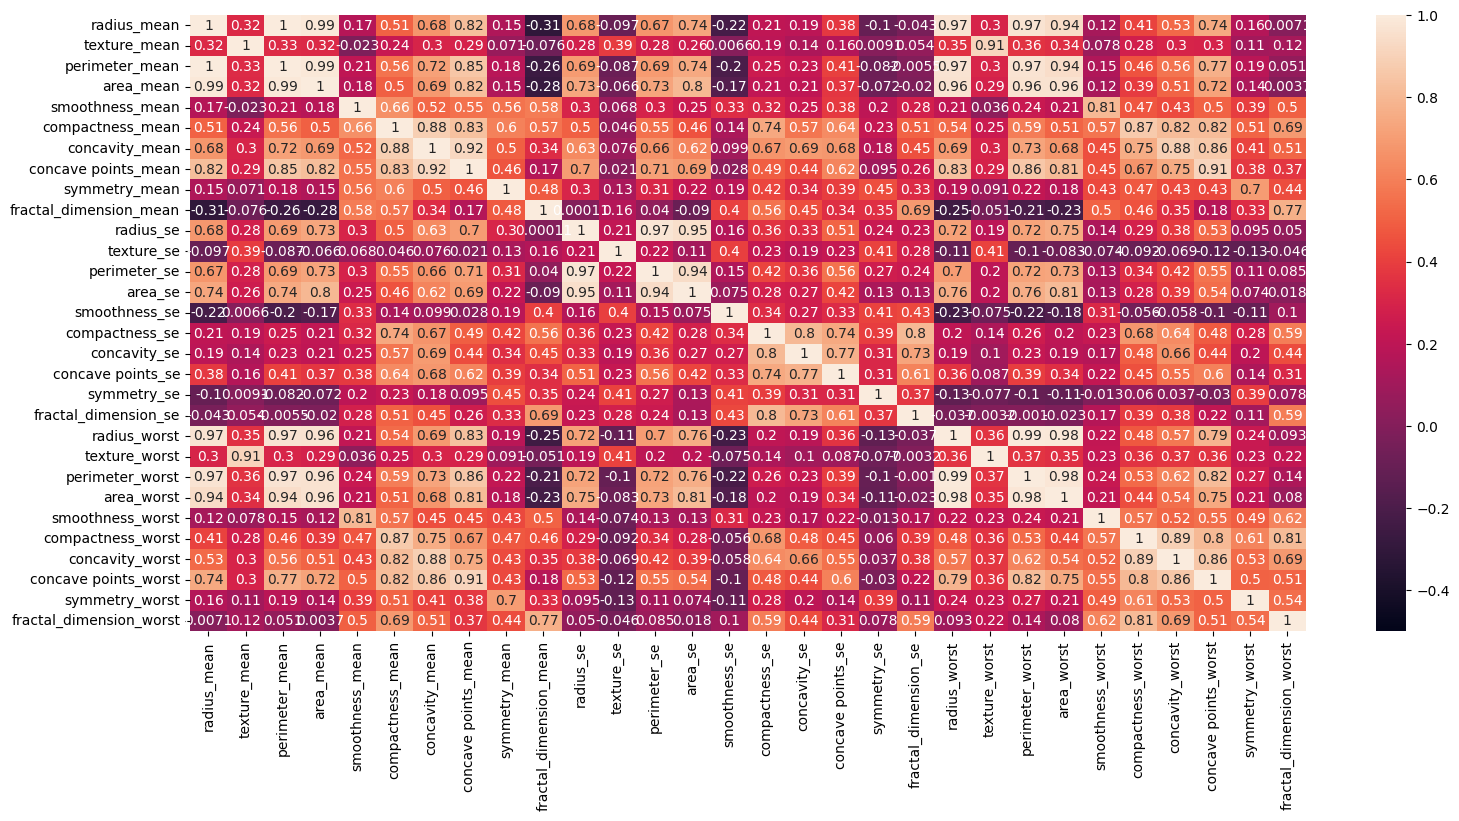

In [45]:
plt.figure(figsize=(18,8))
sns.heatmap(cancer[num_var].corr(), annot=True, vmin=-0.5)
plt.show()

In [46]:
class plot_dist:
    def __init__(self, df: pd.DataFrame, num_var: list, cat_var: list, legend=None):
        self.df = df
        self.num_var = num_var
        self.cat_var = cat_var
        self.legend = legend  # columna target/clase, ej. 'diagnosis'

    def __call__(self):
        # Categóricas
        for x in self.cat_var:
            print('Variable categórica -', x)
            self.plot_cat(x)

        # Numéricas
        for x in self.num_var:
            print('Variable numérica -', x)
            self.plot_num(x)

    def plot_cat(self, x: str):
        """
        Gráfico de pastel para mostrar distribución de variable categórica.
        Si quieres, puedes cambiar a barras (countplot).
        """
        s = self.df[x].astype("category")
        counts = s.value_counts(dropna=False)

        plt.figure(figsize=(3, 3))
        plt.pie(
            counts.values,
            labels=[str(i) for i in counts.index],
            autopct='%1.1f%%',
            startangle=90
        )
        plt.title(f'Distribución de {x}')
        plt.tight_layout()
        plt.show()

    def plot_num(self, x: str):
        """
        Dos gráficos horizontales:
        - Izq: Boxplot por clase (legend) si existe, si no boxplot simple
        - Der: Histograma (con KDE) por clase si existe, si no hist simple
        """
        data = self.df[[x] + ([self.legend] if self.legend else [])].dropna()

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # --- Izquierda: boxplot ---
        """if self.legend:
            sns.boxplot(data=data, x=x, y=self.legend, ax=axes[0])
            axes[0].set_title(f'Boxplot de {x} por {self.legend}')
        else:
            sns.boxplot(data=data, x=x, ax=axes[0])
            axes[0].set_title(f'Boxplot de {x}')"""

        # --- Izquierda: boxplot ---
        if self.legend:
            sns.boxplot(
                data=data,
                x=self.legend,   # clases en eje X
                y=x,             # variable numérica en eje Y
                ax=axes[0]
            )
            axes[0].set_title(f'Boxplot de {x} por {self.legend}')
        else:
            sns.boxplot(data=data, y=x, ax=axes[0])
            axes[0].set_title(f'Boxplot de {x}')

        # --- Derecha: histograma ---
        if self.legend:
            # histplot permite hue para separar clases
            sns.histplot(
                data=data,
                x=x,
                hue=self.legend,
                kde=True,
                stat="density",
                common_norm=False,
                ax=axes[1]
            )
            axes[1].set_title(f'Distribución de {x} por {self.legend}')
        else:
            sns.histplot(data=data, x=x, kde=True, stat="density", ax=axes[1])
            axes[1].set_title(f'Distribución de {x}')

        for ax in axes:
            ax.grid(True, alpha=0.2)

        plt.tight_layout()
        plt.show()


In [47]:
cancer.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

Variable categórica - diagnosis


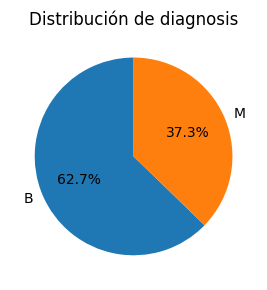

Variable numérica - radius_mean


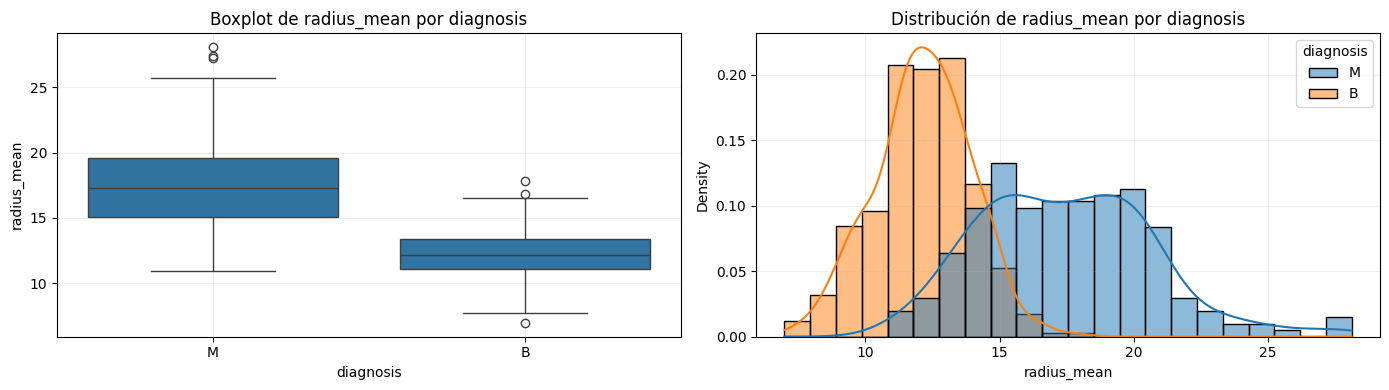

Variable numérica - texture_mean


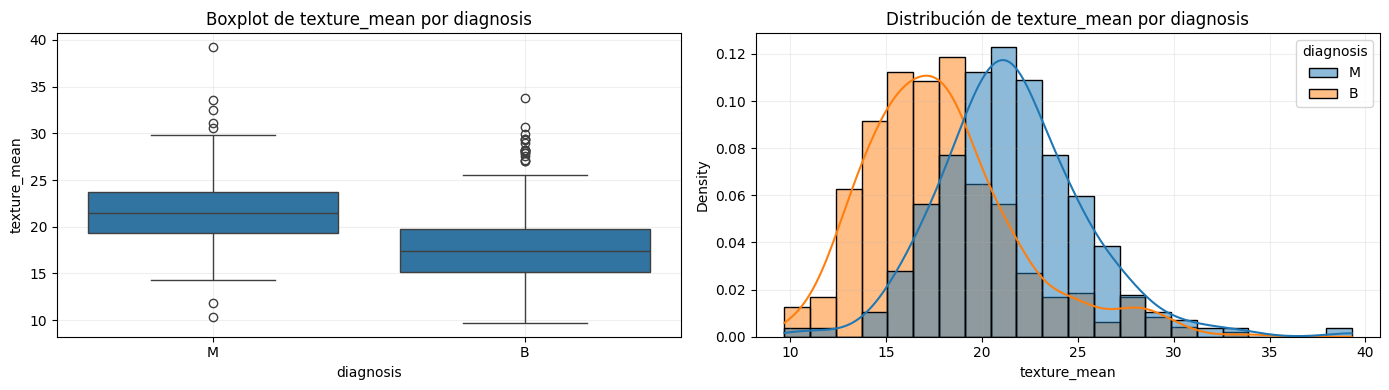

Variable numérica - perimeter_mean


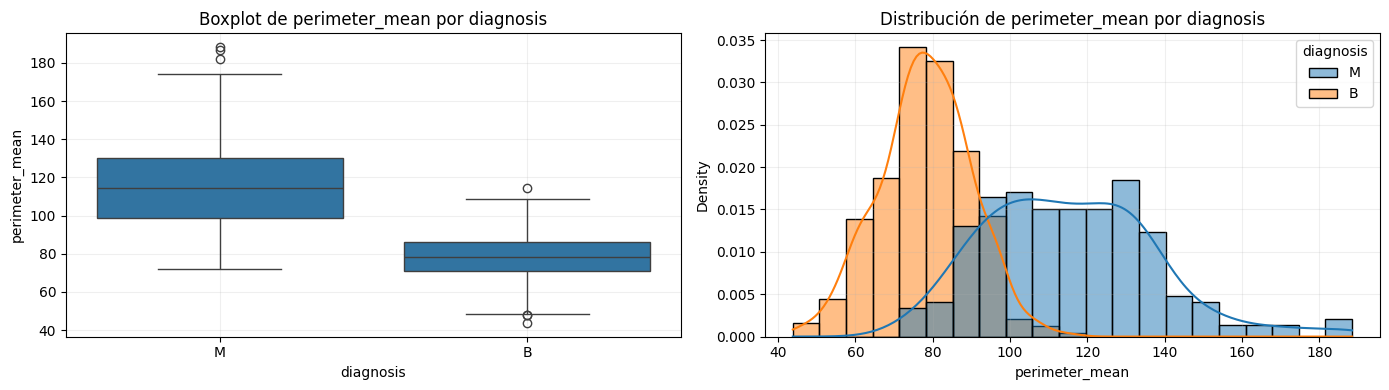

Variable numérica - area_mean


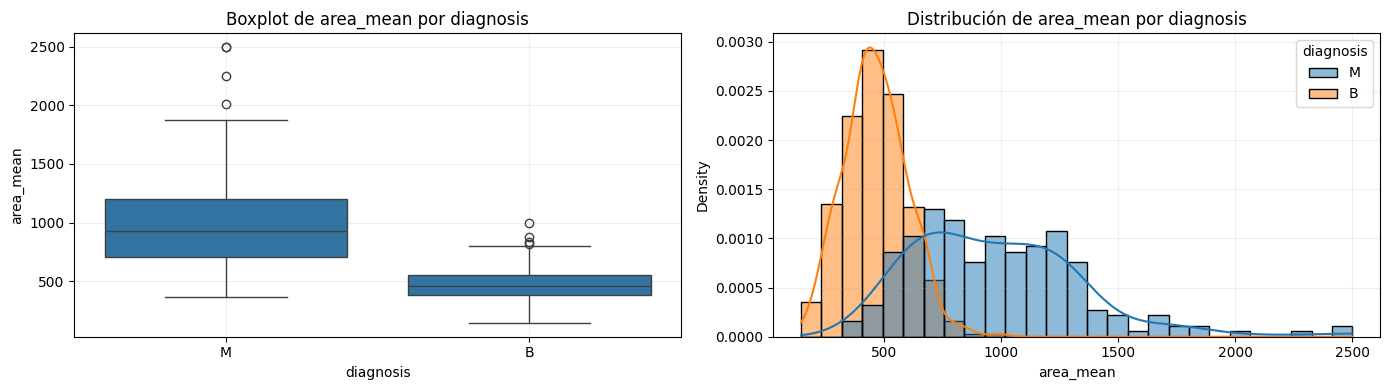

Variable numérica - smoothness_mean


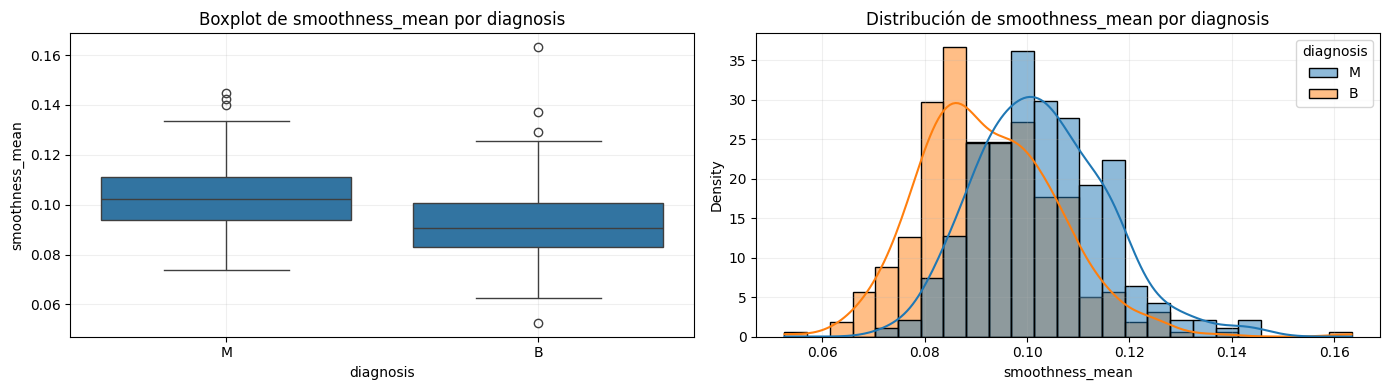

Variable numérica - compactness_mean


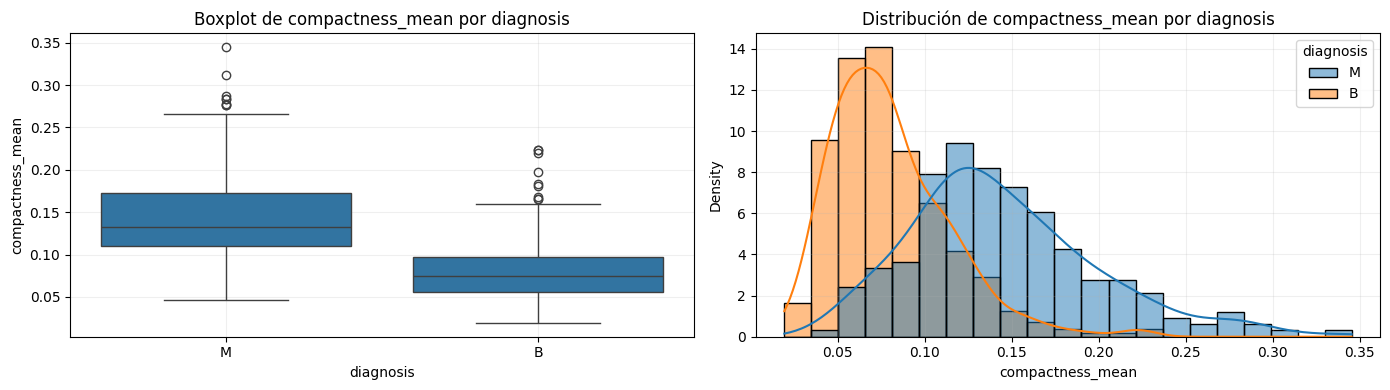

Variable numérica - concavity_mean


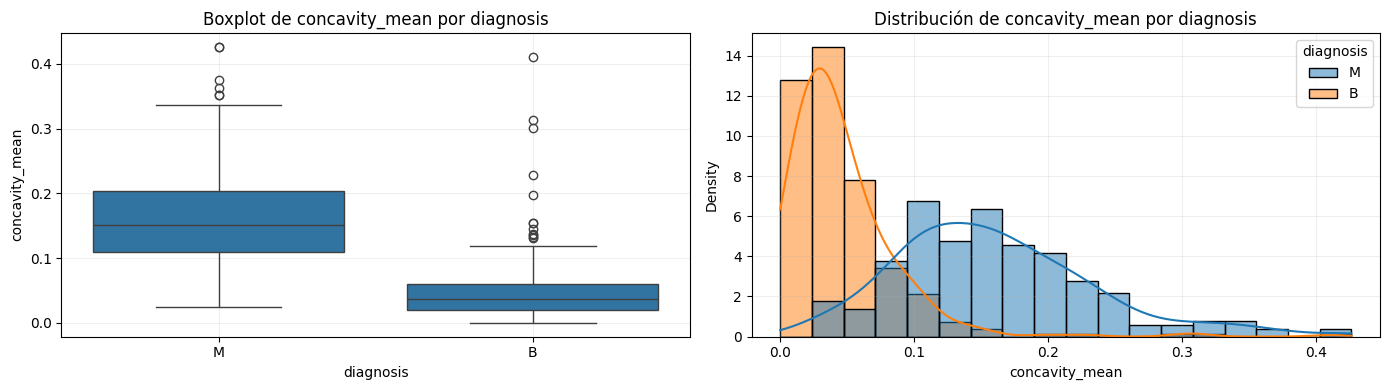

Variable numérica - concave points_mean


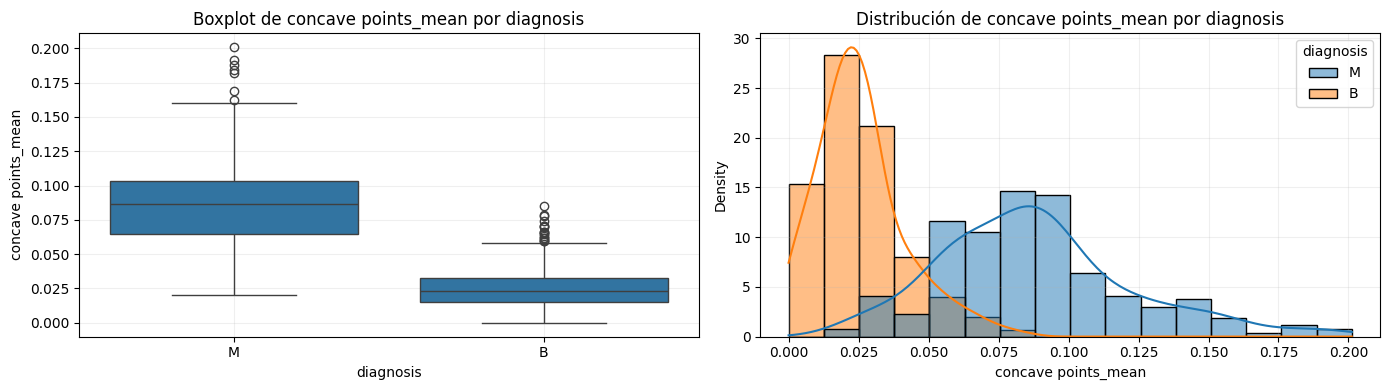

Variable numérica - symmetry_mean


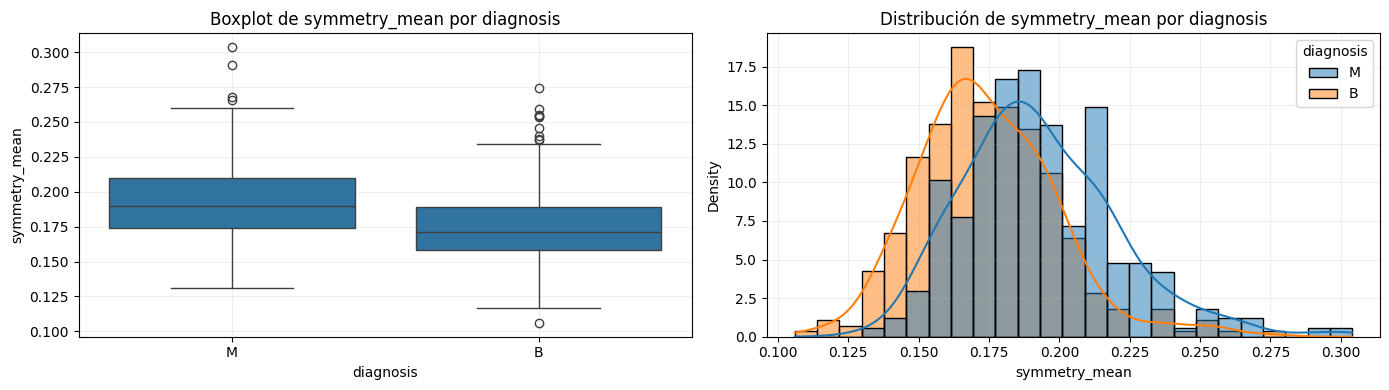

Variable numérica - fractal_dimension_mean


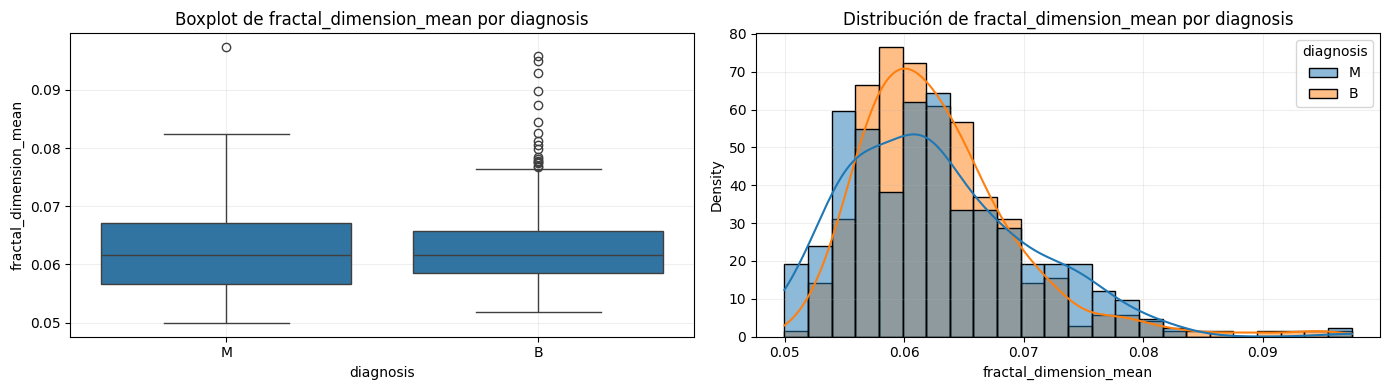

Variable numérica - radius_se


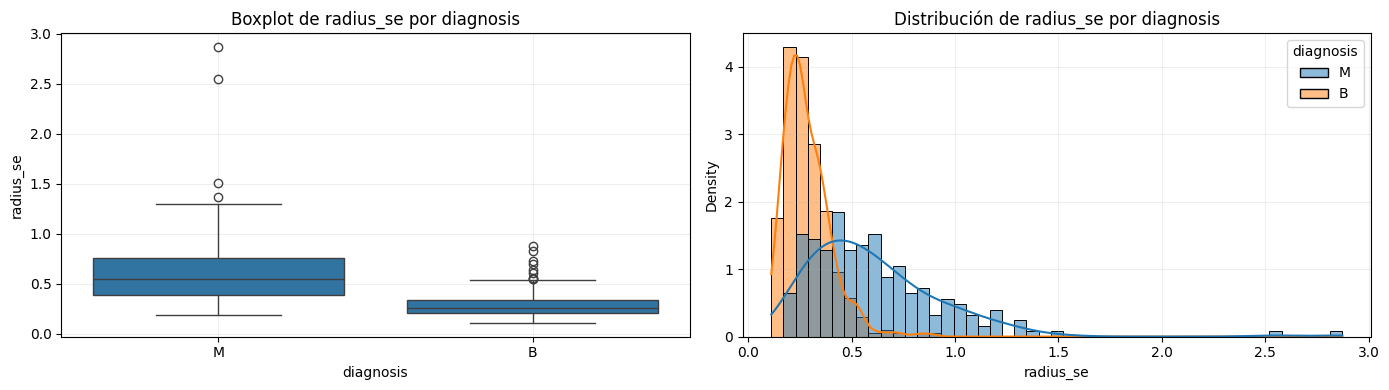

Variable numérica - texture_se


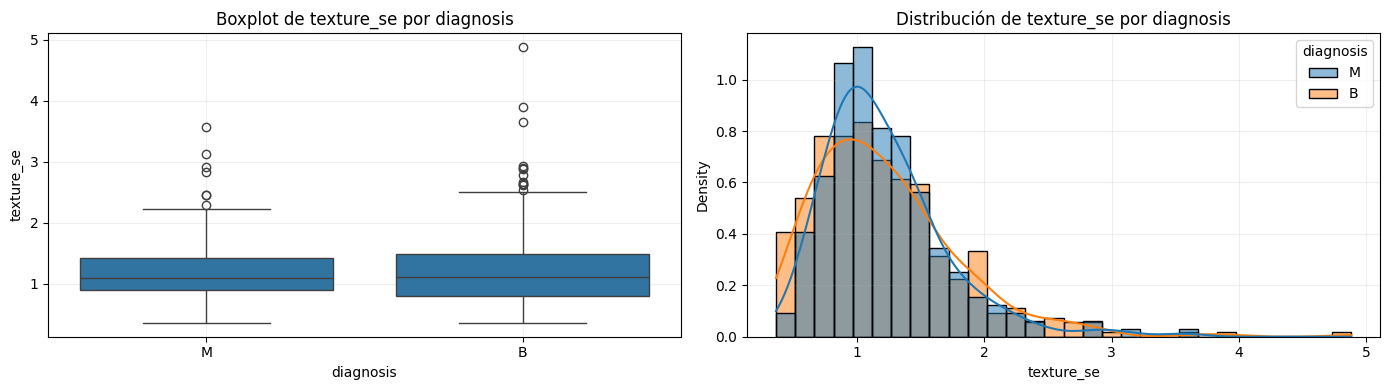

Variable numérica - perimeter_se


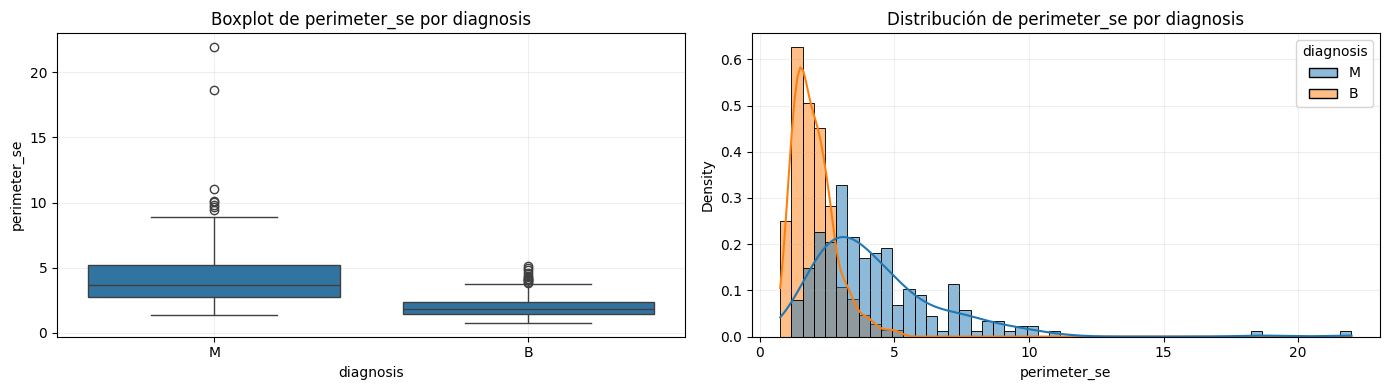

Variable numérica - area_se


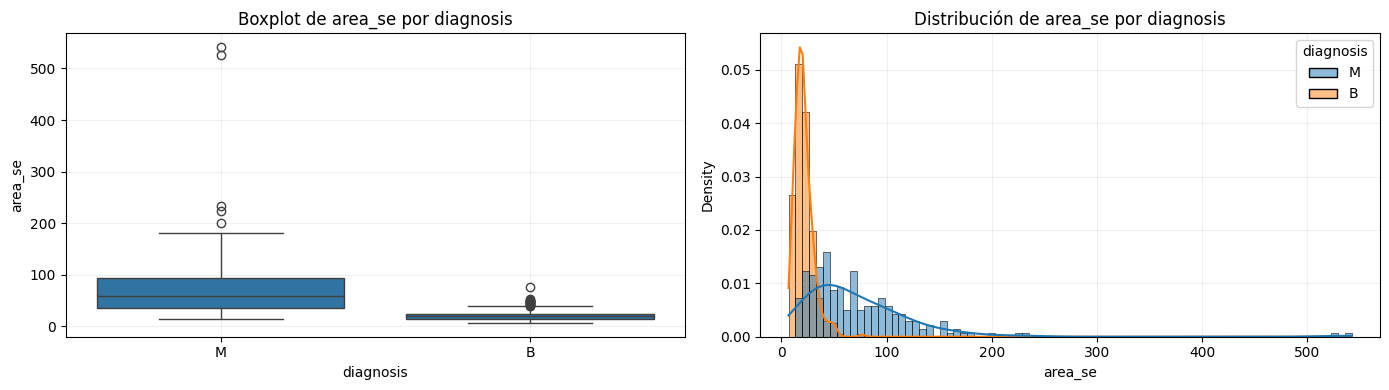

Variable numérica - smoothness_se


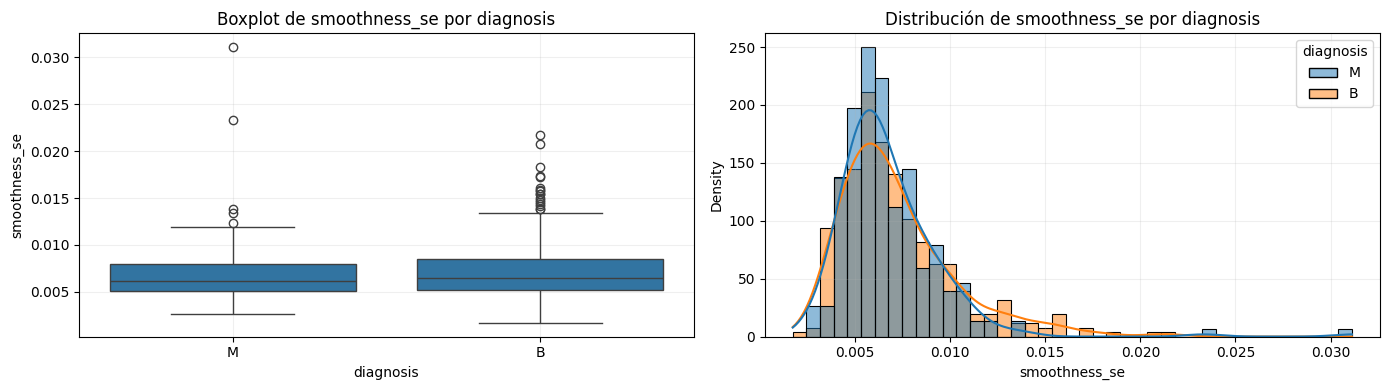

Variable numérica - compactness_se


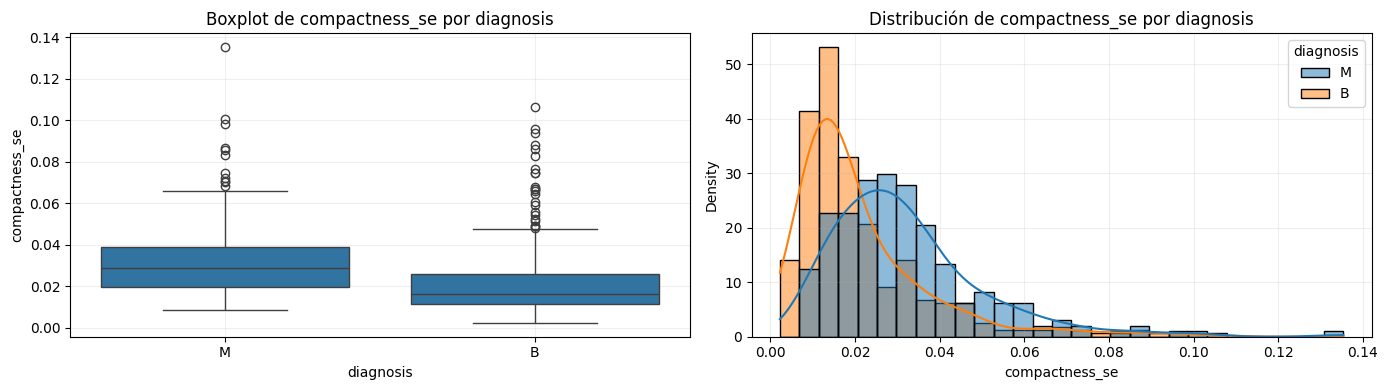

Variable numérica - concavity_se


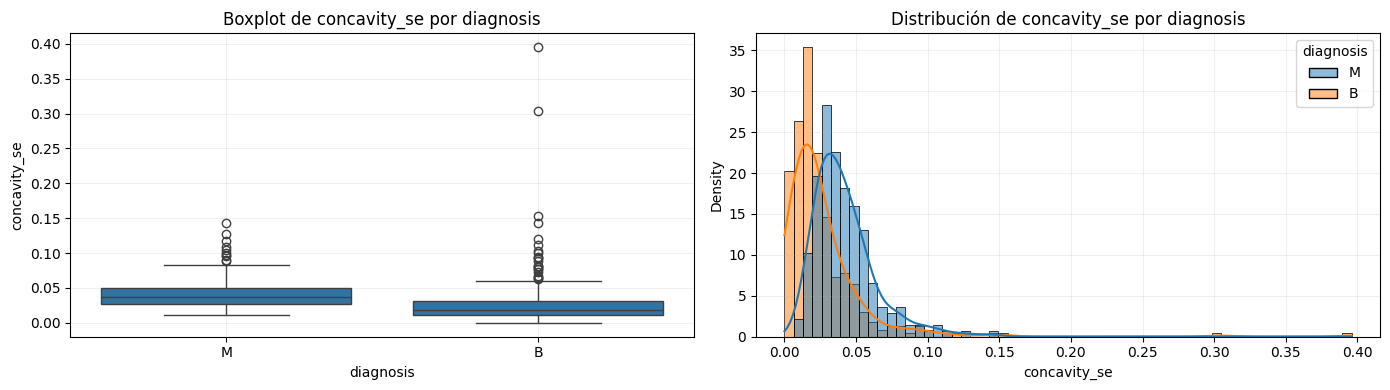

Variable numérica - concave points_se


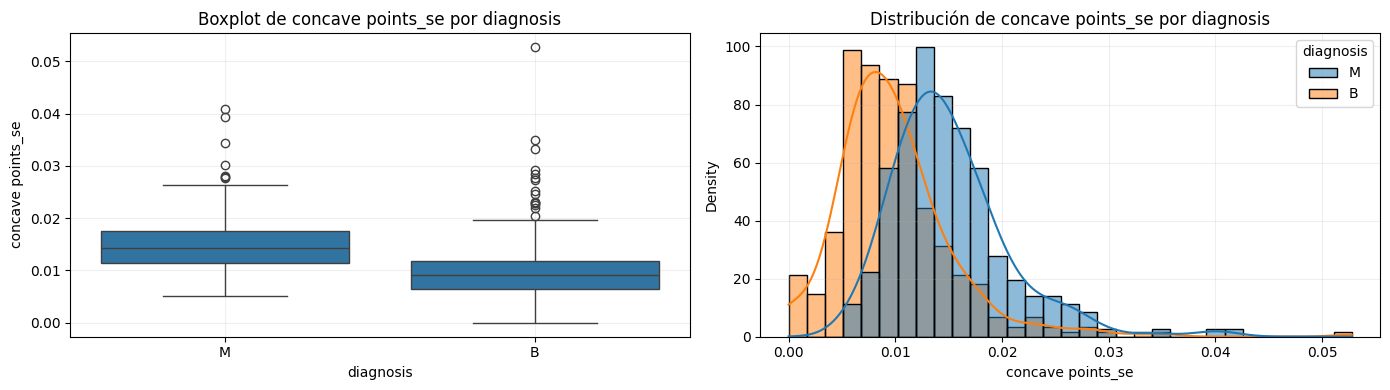

Variable numérica - symmetry_se


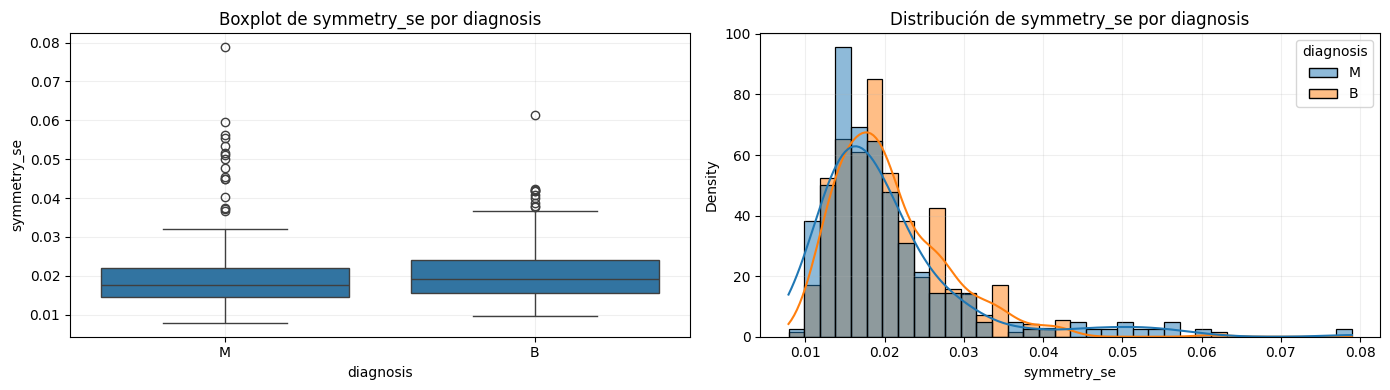

Variable numérica - fractal_dimension_se


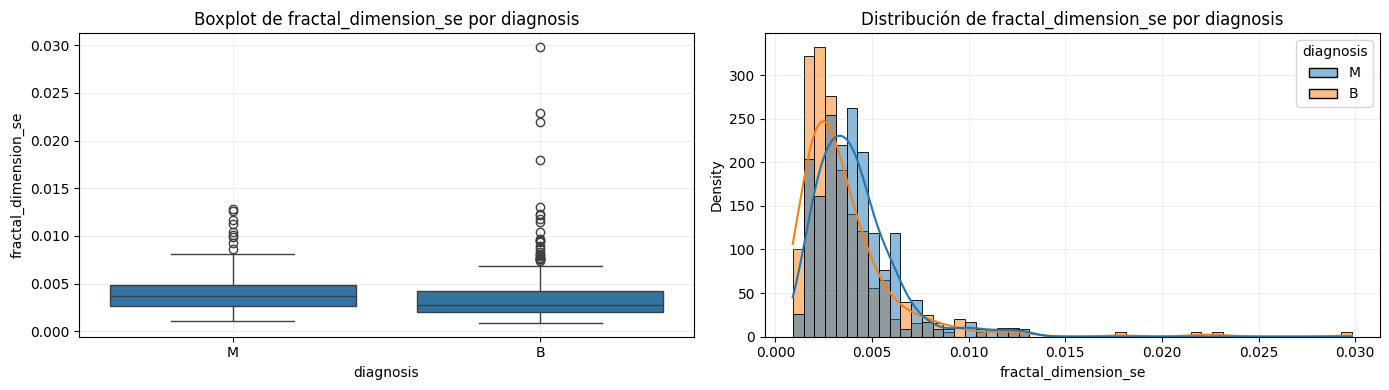

Variable numérica - radius_worst


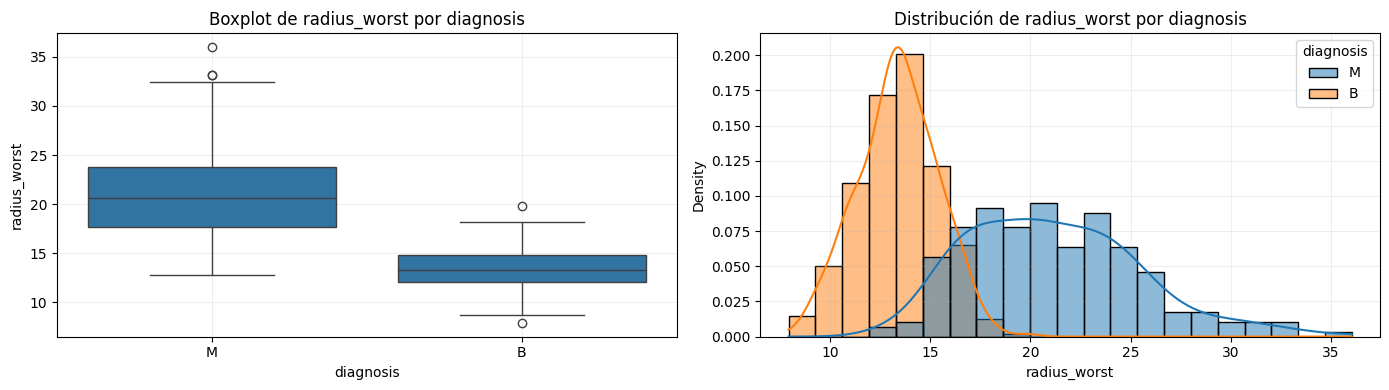

Variable numérica - texture_worst


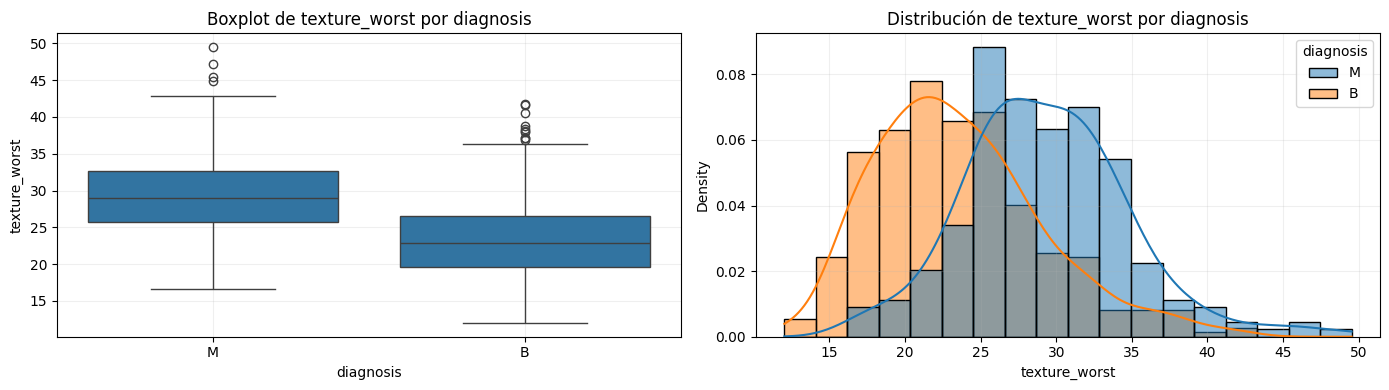

Variable numérica - perimeter_worst


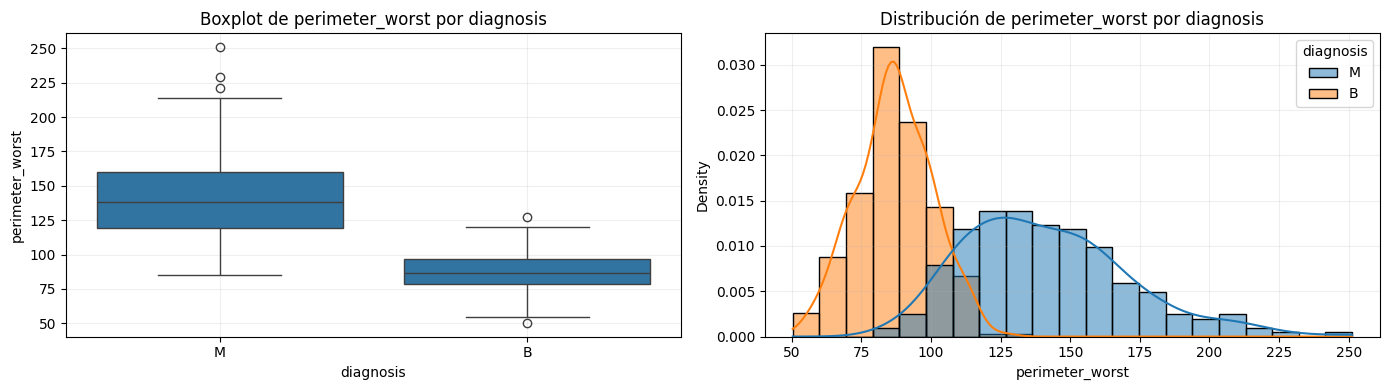

Variable numérica - area_worst


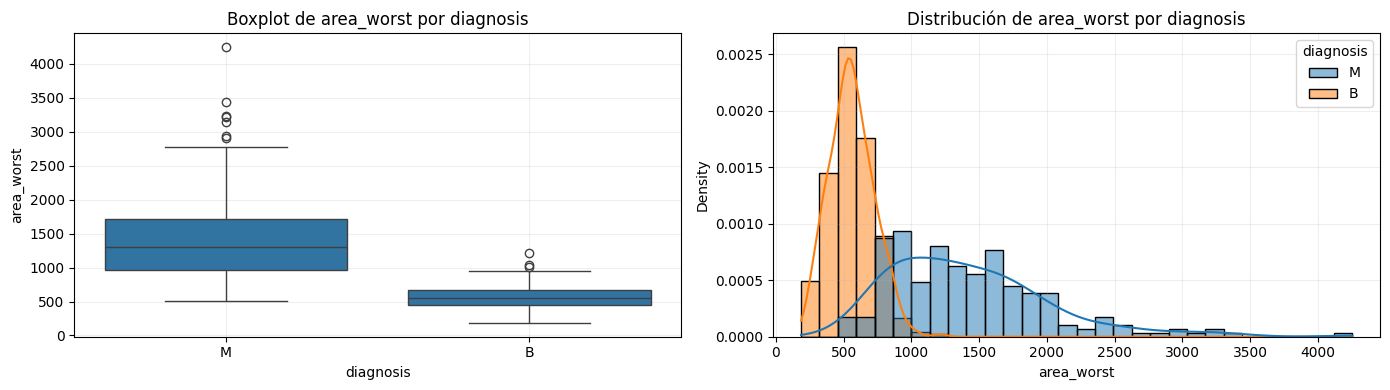

Variable numérica - smoothness_worst


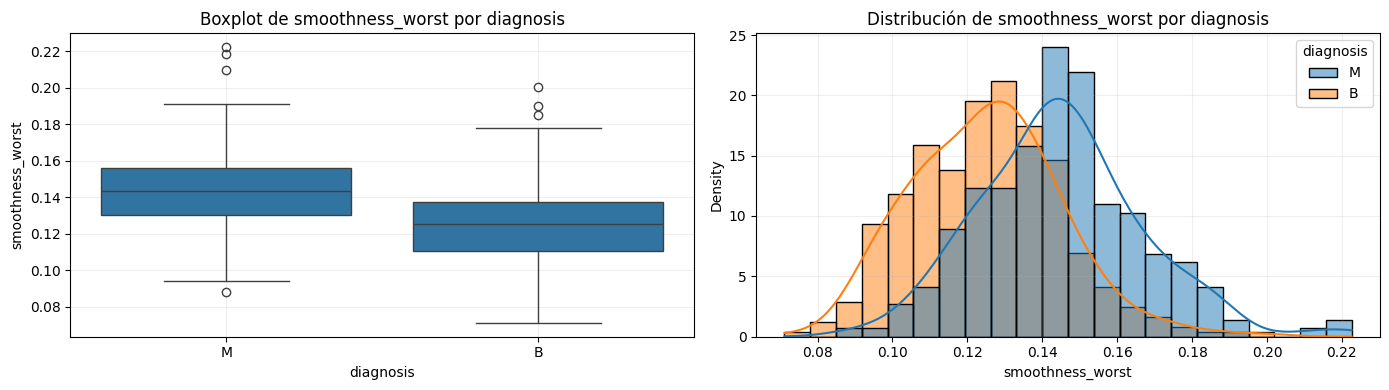

Variable numérica - compactness_worst


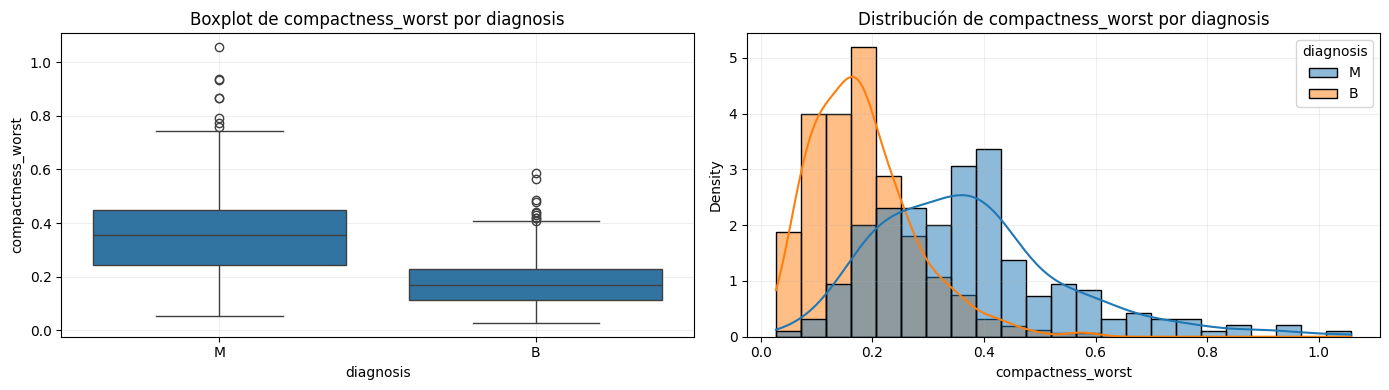

Variable numérica - concavity_worst


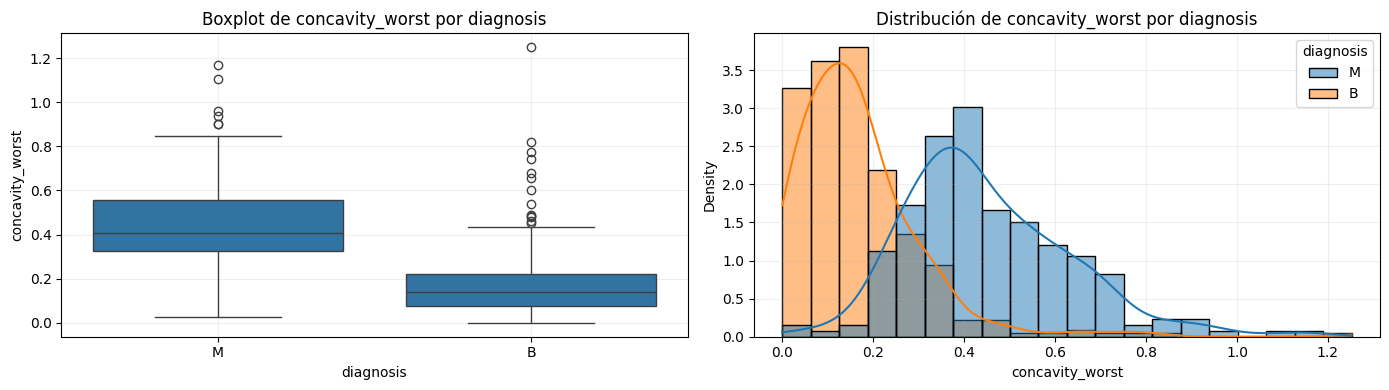

Variable numérica - concave points_worst


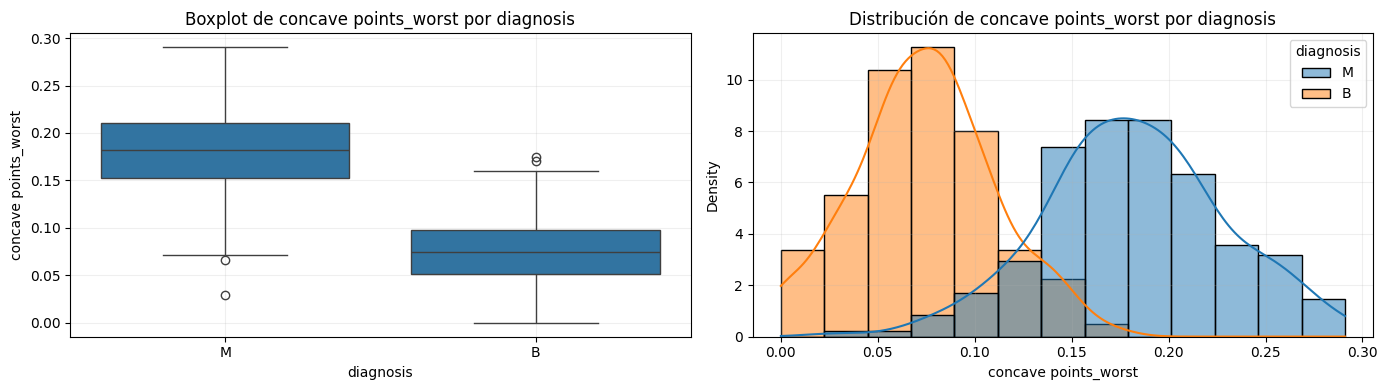

Variable numérica - symmetry_worst


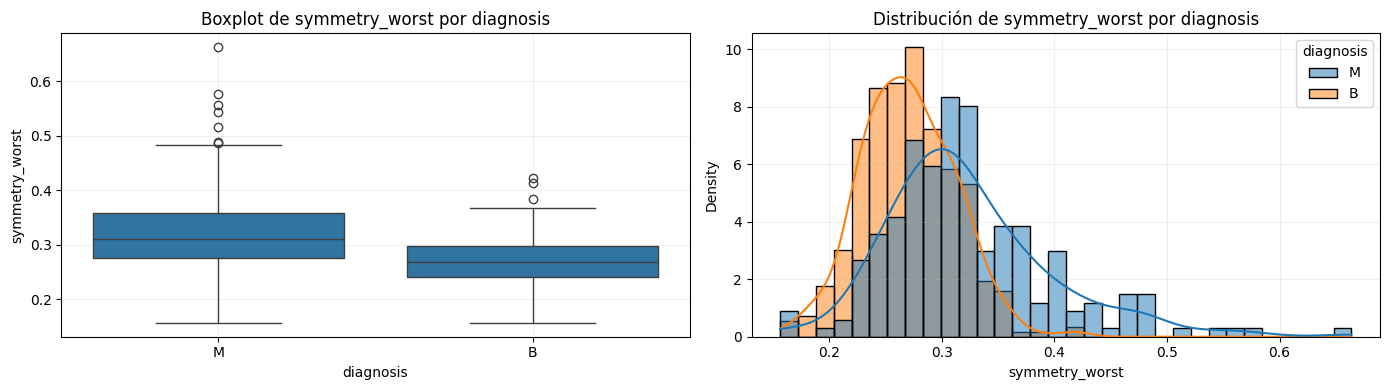

Variable numérica - fractal_dimension_worst


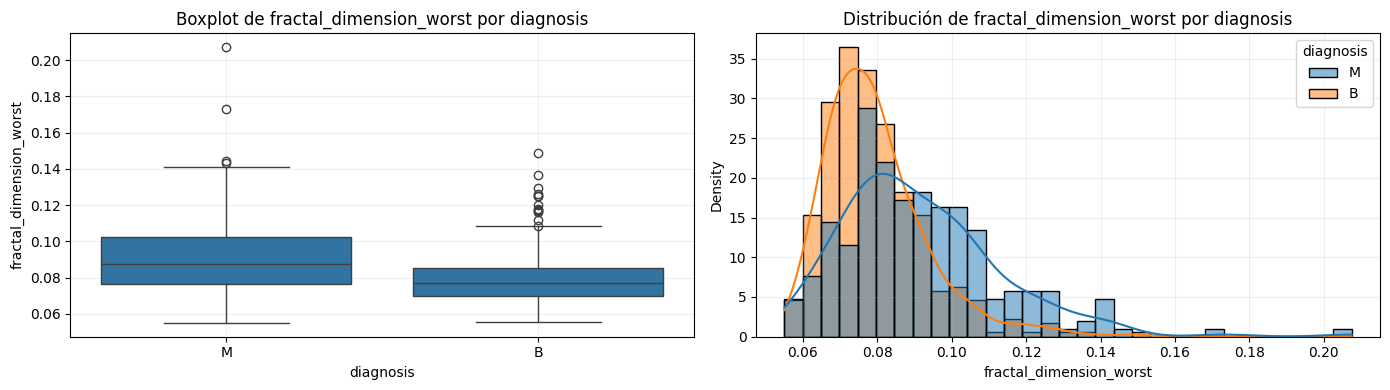

In [47]:
plot_dist(cancer, num_var, cat_var, 'diagnosis')() # diagnosis = B - Benigno / M - Maligno

In [48]:
cancer['id'].unique().__len__()/cancer.shape[0]

1.0

## Escalamiento

In [49]:
y = cancer['diagnosis'].astype(str)

X = cancer.drop(columns=['id', 'diagnosis']) # numéricas

# Escalado (recomendado para PCA/FA/UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape, "| X_scaled shape:", X_scaled.shape)
print("Clases:", y.value_counts().to_dict())

X shape: (569, 30) | X_scaled shape: (569, 30)
Clases: {'B': 357, 'M': 212}


## Outliers

In [50]:
X_m = X_scaled.copy()

# Media y covarianza
mean_vec = np.mean(X_m, axis=0)
cov_mat = np.cov(X_m, rowvar=False)
inv_cov_mat = np.linalg.inv(cov_mat)

# Distancia de Mahalanobis
def mahalanobis_distance(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(diff @ inv_cov @ diff.T)

md = np.array([mahalanobis_distance(x, mean_vec, inv_cov_mat) for x in X_m])

In [51]:
alpha = 0.001  # nivel de significancia (estricto)
threshold = np.sqrt(chi2_dist.ppf(1 - alpha, df=X_m.shape[1]))

print("Umbral Mahalanobis:", threshold)

Umbral Mahalanobis: 7.726775802650802


In [52]:
outliers_md = md > threshold

print("Número de outliers:", outliers_md.sum())
print("Porcentaje:", outliers_md.mean() * 100)

Número de outliers: 48
Porcentaje: 8.43585237258348


In [53]:
df_out = cancer.copy()
df_out["mahalanobis"] = md
df_out["outlier_md"] = outliers_md

In [54]:
df_out[outliers_md].diagnosis.value_counts().to_dict()

{'M': 31, 'B': 17}

In [55]:
index_to_drop = index = df_out[outliers_md].index
X_scaled_wo = pd.DataFrame(X_scaled).drop(index_to_drop).values

Los valores atípicos multivariados fueron identificados utilizando la distancia de Mahalanobis, la cual considera la correlación entre variables. El umbral fue determinado mediante la distribución chi-cuadrada, asumiendo un nivel de significancia del 0.1%. Los outliers identificados no se eliminaron automáticamente, dado su posible significado clínico y que representa un 8.4% de la muestra la cual ya es algo pequeña y podríamos perder información de tumores malignos.

### PCA

In [56]:
print('Variables numéricas -', X_scaled.shape[1])

Variables numéricas - 30


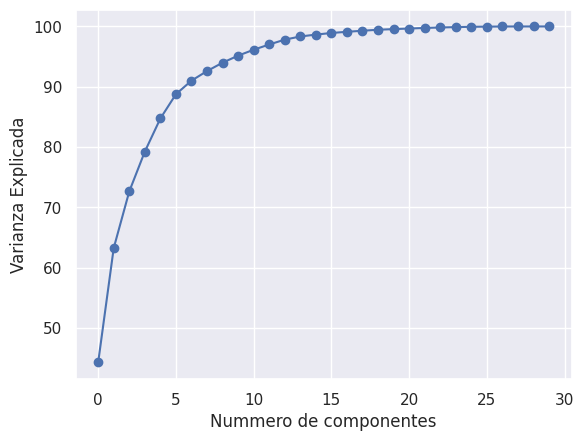

In [57]:
sns.set_theme(style="darkgrid", context="notebook")  # <-- fondo gris y grid suave

pca_30 = PCA(n_components=X_scaled.shape[1])
pca_30.fit(X_scaled)

plt.grid()
plt.plot(np.cumsum(pca_30.explained_variance_ratio_ * 100), marker='o')
#sns.scatterplot(np.cumsum(pca_30.explained_variance_ratio_ * 100))
plt.xlabel('Nummero de componentes')
plt.ylabel('Varianza Explicada')

plt.grid()
plt.show()

PCA explained variance ratio: [0.44272026 0.18971182]  | acumulada: 0.6324320765155944


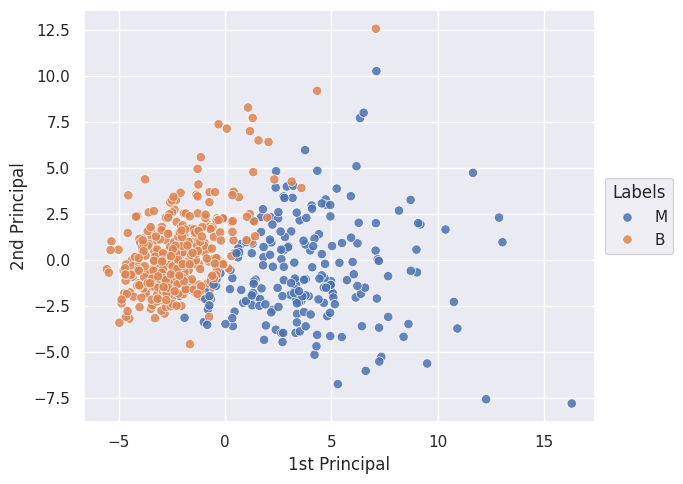

In [58]:
sns.set_theme(style="darkgrid", context="notebook")  # <-- fondo gris y grid suave

pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_scaled)

print("PCA explained variance ratio:", pca.explained_variance_ratio_,
      " | acumulada:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(Z_pca, columns=["1st Principal", "2nd Principal"])
pca_df["Labels"] = y  # B/M

plt.figure(figsize=(7,5))
ax = sns.scatterplot(
    data=pca_df,
    x="1st Principal",
    y="2nd Principal",
    hue="Labels",
    alpha=0.85,
    s=45
)

ax.set_title("")
ax.set_xlabel("1st Principal")
ax.set_ylabel("2nd Principal")

# leyenda a la derecha, como la profe
ax.legend(title="Labels", bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0)

plt.tight_layout()
plt.show()

PCA explained variance ratio: [0.45975501 0.17537106]  | acumulada: 0.6351260667590959


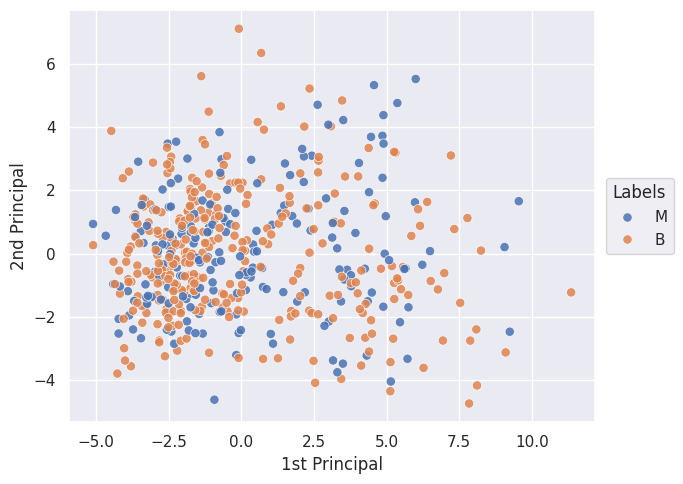

In [59]:
sns.set_theme(style="darkgrid", context="notebook")  # <-- fondo gris y grid suave

pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_scaled_wo)

print("PCA explained variance ratio:", pca.explained_variance_ratio_,
      " | acumulada:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame(Z_pca, columns=["1st Principal", "2nd Principal"])
pca_df["Labels"] = y  # B/M

plt.figure(figsize=(7,5))
ax = sns.scatterplot(
    data=pca_df,
    x="1st Principal",
    y="2nd Principal",
    hue="Labels",
    alpha=0.85,
    s=45
)

ax.set_title("")
ax.set_xlabel("1st Principal")
ax.set_ylabel("2nd Principal")

# leyenda a la derecha, como la profe
ax.legend(title="Labels", bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0)

plt.tight_layout()
plt.show()

* Sin valores atípicos se pierde clasificación de los tumores, los puntos se encuentran más interpuestos.

### Análisis Factorial

In [60]:
kmo_all, kmo_model = calculate_kmo(X_scaled)
chi2, p_value = calculate_bartlett_sphericity(X_scaled)

print(f"KMO: {kmo_model:.4f}")
print(f"Bartlett Chi2: {chi2:.2f} | p-value: {p_value:.4e}")

KMO: 0.8322
Bartlett Chi2: 39362.12 | p-value: 0.0000e+00


/home/erick/Entorno/lib/python3.10/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


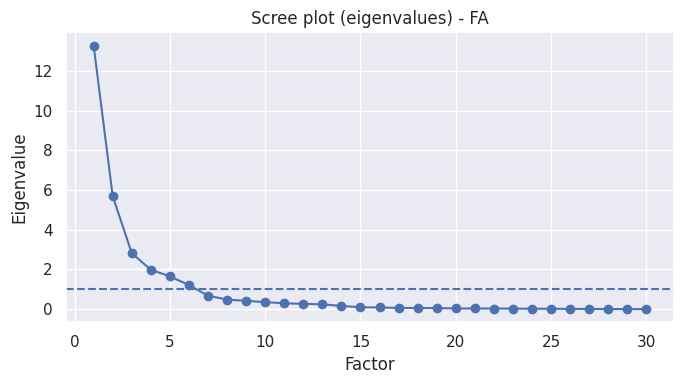

Factores sugeridos por Kaiser (ev>1): 6


In [61]:
fa_tmp = FactorAnalyzer(n_factors=X.shape[1], rotation=None, method="minres")
fa_tmp.fit(X_scaled)
ev, v = fa_tmp.get_eigenvalues()

plt.figure(figsize=(7,4))
plt.plot(range(1, len(ev)+1), ev, marker="o")
plt.axhline(1, linestyle="--")
plt.title("Scree plot (eigenvalues) - FA")
plt.xlabel("Factor")
plt.ylabel("Eigenvalue")
plt.tight_layout()
plt.show()

n_factors = int(np.sum(ev > 1))
print("Factores sugeridos por Kaiser (ev>1):", n_factors)

* La prueba de esfericidad de Bartlett resultó estadísticamente significativa (p < 0.05), indicando que la matriz de correlaciones difiere de la matriz identidad y que existen correlaciones relevantes entre las variables, lo cual justifica la aplicación del análisis factorial.
* Aunque el criterio de Kaiser sugiere un número mayor de factores, en este trabajo se utilizan dos factores con fines de visualización, de manera consistente con el análisis mediante PCA y UMAP.
* El análisis factorial es un método no supervisado cuyo objetivo es explicar la varianza común entre variables, no maximizar la separación entre clases diagnósticas.

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


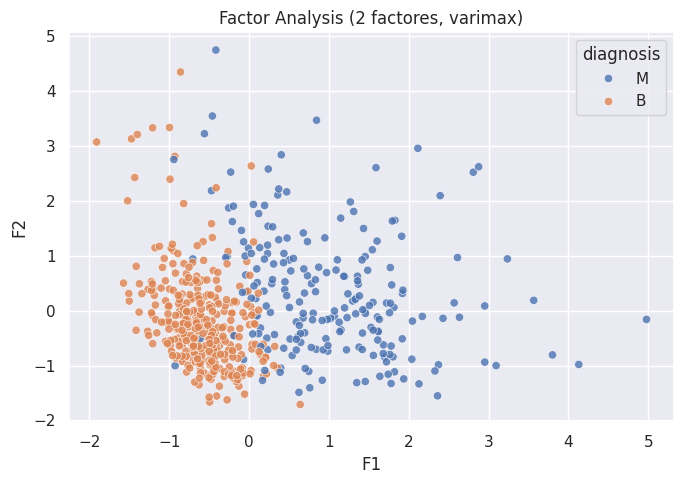

In [62]:
fa = FactorAnalyzer(n_factors=2, rotation="varimax", method="minres")
fa.fit(X_scaled)

Z_fa = fa.transform(X_scaled)

fa_df = pd.DataFrame(Z_fa, columns=["F1", "F2"])
fa_df['diagnosis'] = y.values

plt.figure(figsize=(7, 5))
sns.scatterplot(data=fa_df, x="F1", y="F2", hue='diagnosis', alpha=0.8)
plt.title("Factor Analysis (2 factores, varimax)")
plt.tight_layout()
plt.show()

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


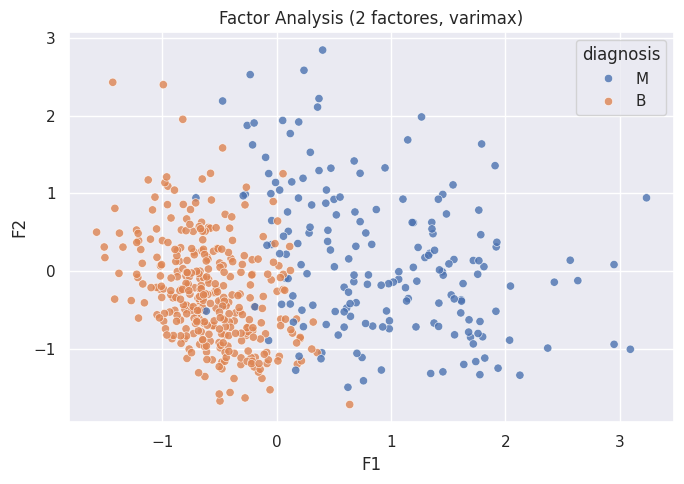

In [63]:
fa = FactorAnalyzer(n_factors=2, rotation="varimax", method="minres")
fa.fit(X_scaled)

Z_fa = fa.transform(X_scaled_wo)

fa_df = pd.DataFrame(Z_fa, columns=["F1", "F2"])
fa_df['diagnosis'] = [z for i,z in enumerate(y) if i not in index_to_drop]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=fa_df, x="F1", y="F2", hue='diagnosis', alpha=0.8)
plt.title("Factor Analysis (2 factores, varimax)")
plt.tight_layout()
plt.show()

* Encontramos menos separación entre los puntos sin outliers vs PCA, sin embargo, dejando los outliers hay mejor concentración de los puntos de tumores benignos.

### UMAP

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


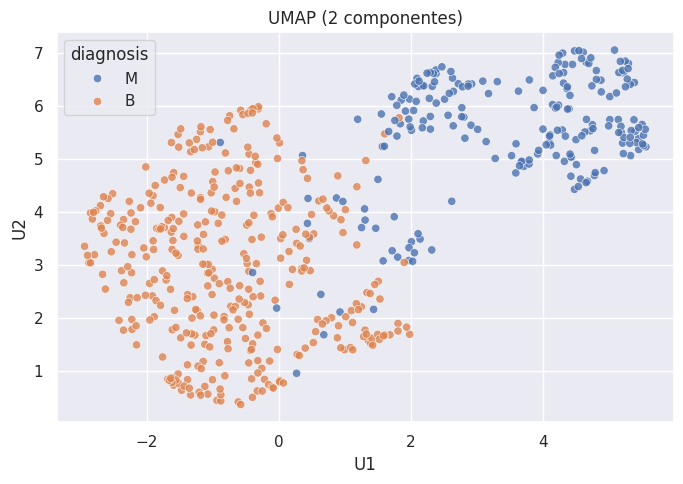

In [64]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

Z_umap = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame(Z_umap, columns=["U1", "U2"])
umap_df['diagnosis'] = y.values

plt.figure(figsize=(7, 5))
sns.scatterplot(data=umap_df, x="U1", y="U2", hue='diagnosis', alpha=0.8)
plt.title("UMAP (2 componentes)")
plt.tight_layout()
plt.show()

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


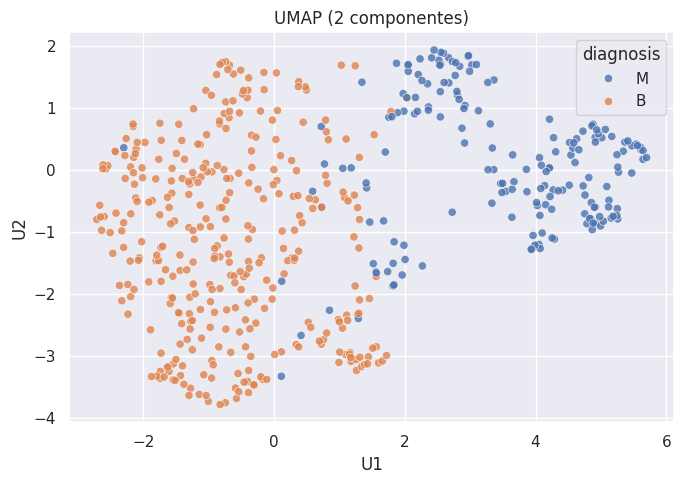

In [65]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

Z_umap = reducer.fit_transform(X_scaled_wo)

umap_df = pd.DataFrame(Z_umap, columns=["U1", "U2"])
umap_df['diagnosis'] = [z for i,z in enumerate(y) if i not in index_to_drop]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=umap_df, x="U1", y="U2", hue='diagnosis', alpha=0.8)
plt.title("UMAP (2 componentes)")
plt.tight_layout()
plt.show()

### Prueba MANOVA

In [66]:
Z_pca = pca.fit_transform(X_scaled)
Z_fa = fa.transform(X_scaled)
Z_umap = reducer.fit_transform(X_scaled)

def manova_test(Z, y, name=""):
    manova_df = pd.DataFrame(Z, columns=["Z1", "Z2"])
    manova_df["group"] = y.values
    ma = MANOVA.from_formula("Z1 + Z2 ~ group", data=manova_df)  # <- línea clave
    print("\n" + "="*60)
    print(f"MANOVA - {name}")
    print(ma.mv_test())

manova_test(Z_pca, y, "PCA (PC1, PC2)")
manova_test(Z_fa, y, "FA (F1, F2)")
manova_test(Z_umap, y, "UMAP (U1, U2)")

/home/erick/Entorno/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



MANOVA - PCA (PC1, PC2)
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.5884 2.0000 566.0000 197.9662 0.0000
         Pillai's trace 0.4116 2.0000 566.0000 197.9662 0.0000
 Hotelling-Lawley trace 0.6995 2.0000 566.0000 197.9662 0.0000
    Roy's greatest root 0.6995 2.0000 566.0000 197.9662 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
         group          Value  Num DF  Den DF  F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.3475 2.0000 566.0000 531.3338 0.0000
         Pillai's trace 0.6525 2.0000 566.0000 53

> $H_{0}$ : Los centroides multivariados de B y M son iguales. <br>
> $H_{1}$ : Al menos uno de los centroides difiere.

| Método   | Wilks’ λ ↓ | F ↑      | Conclusión                |
| -------- | ---------- | -------- | ------------------------- |
| PCA      | ~0.347     | ~531     | Muy buena separación      |
| FA       | ~0.355     | ~513     | Buena separación          |
| **UMAP** | **~0.245** | **~874** | **Separación más fuerte** |

* En los tres métodos se rechaza $H_{0}$
* Existe evidencia estadística de separación entre tumores benignos y malignos en el espacio reducido
* PCA y FA permiten interpretabilidad
* UMAP maximiza la separación visual

## Conclusión

Se aplicaron métodos de reducción de dimensionalidad (PCA, Análisis Factorial y UMAP) para explorar la estructura del conjunto de datos y analizar la separación entre tumores benignos y malignos. Previamente, los datos fueron estandarizados y se eliminó el identificador, al no aportar información relevante para el análisis.

La adecuación del Análisis Factorial fue confirmada mediante el índice KMO y la prueba de esfericidad de Bartlett, ambos favorables. Aunque el criterio de Kaiser sugiere la retención de un mayor número de factores, se utilizaron dos dimensiones con fines de visualización y comparación entre métodos.

Los resultados visuales fueron respaldados mediante la prueba MANOVA, la cual resultó estadísticamente significativa en los tres métodos, indicando diferencias multivariadas entre ambos diagnósticos. UMAP mostró la mayor separación visual, mientras que PCA y Análisis Factorial ofrecieron mayor interpretabilidad. En conjunto, los métodos se complementan y permiten una exploración multivariada robusta del problema.

#### Análisis de Componentes Principales (PCA)

In [67]:
loadings_pca = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1_loading", "PC2_loading"]
).sort_values("PC1_loading", key=np.abs, ascending=False)

loadings_pca.head(10)

,PC1_loading,PC2_loading
concave points_mean,0.260854,-0.034768
concavity_mean,0.258400,0.060165
concave points_worst,0.250886,-0.008257
compactness_mean,0.239285,0.151892
perimeter_worst,0.236640,-0.199878
concavity_worst,0.228768,0.097964
radius_worst,0.227997,-0.219866
perimeter_mean,0.227537,-0.215181
area_worst,0.224871,-0.219352
area_mean,0.220995,-0.231077


In [68]:
loadings_pca = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1_loading", "PC2_loading"]
).sort_values("PC2_loading", key=np.abs, ascending=False)

loadings_pca.head(10)

,PC1_loading,PC2_loading
fractal_dimension_mean,0.064363,0.366575
fractal_dimension_se,0.102568,0.280092
fractal_dimension_worst,0.131784,0.275339
radius_mean,0.218902,-0.233857
compactness_se,0.170393,0.232716
area_mean,0.220995,-0.231077
radius_worst,0.227997,-0.219866
area_worst,0.224871,-0.219352
perimeter_mean,0.227537,-0.215181
smoothness_se,0.014531,0.204430


> **PC1** <br>
> El primer componente principal (PC1) está dominado por variables relacionadas con el tamaño y la irregularidad del tumor, como área, perímetro, radio y medidas de concavidad. Este componente captura la variabilidad asociada a tumores más grandes y con geometría más compleja, lo cual resulta relevante para la diferenciación entre tumores benignos y malignos.

> **PC2** <br>
> El segundo componente principal (PC2) está influenciado principalmente por variables asociadas a la complejidad y variabilidad local del contorno, tales como la dimensión fractal y medidas de error estándar. Este componente refleja patrones más finos de textura y rugosidad, y explica una menor proporción de la varianza total en comparación con PC1.

#### Análisis Factorial

In [69]:
loadings_fa = pd.DataFrame(
    fa.loadings_,
    index=X.columns,
    columns=[f"F{i+1}" for i in range(fa.loadings_.shape[1])]
)

In [70]:
top_n = 10
for c in loadings_fa.columns:
    print(f"\nTop {top_n} variables - {c} (por |carga|)")
    print(loadings_fa[c].sort_values(key=np.abs, ascending=False).head(top_n).to_string())


Top 10 variables - F1 (por |carga|)
perimeter_worst         0.990383
radius_worst            0.988088
area_mean               0.979915
perimeter_mean          0.979662
radius_mean             0.975836
area_worst              0.975398
concave points_mean     0.854743
area_se                 0.799777
concave points_worst    0.783867
radius_se               0.750969

Top 10 variables - F2 (por |carga|)
fractal_dimension_mean     0.869792
fractal_dimension_worst    0.796114
compactness_se             0.781898
compactness_mean           0.774648
fractal_dimension_se       0.732090
compactness_worst          0.687517
concavity_se               0.664141
concavity_worst            0.634325
concavity_mean             0.620901
smoothness_mean            0.613751


In [71]:
thr = 0.30
(loadings_fa
 .style
 .format("{:.3f}")
 .background_gradient(cmap=cm, axis=None)
 .applymap(lambda v: "opacity: 0.25;" if abs(v) < thr else "")
)


/tmp/ipykernel_9966/3546454718.py:6: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: "opacity: 0.25;" if abs(v) < thr else "")


,F1,F2
radius_mean,0.976,-0.068
texture_mean,0.366,0.081
perimeter_mean,0.980,-0.012
area_mean,0.980,-0.059
smoothness_mean,0.217,0.614
compactness_mean,0.555,0.775
concavity_mean,0.729,0.621
concave points_mean,0.855,0.427
symmetry_mean,0.199,0.611
fractal_dimension_mean,-0.248,0.870


El Análisis Factorial reveló una estructura clara de dos factores latentes. El primer factor (F1) agrupa variables relacionadas con el tamaño y la irregularidad global del tumor, mientras que el segundo factor (F2) está asociado a la complejidad y variabilidad local del contorno. Esta estructura es consistente con los resultados obtenidos mediante PCA, donde el primer componente capturó variaciones de tamaño y el segundo reflejó patrones más finos de textura. Sin embargo, el análisis factorial facilita una interpretación conceptual más directa al identificar constructos latentes subyacentes en los datos.

> PCA permitió identificar las principales fuentes de variabilidad asociadas al tamaño e irregularidad del tumor, aunque con limitaciones para capturar relaciones no lineales. El Análisis Factorial complementó este enfoque al identificar factores latentes interpretables, diferenciando entre variabilidad global y patrones locales de textura. Por su parte, UMAP, como método no lineal, ofreció la mejor separación visual entre grupos al preservar relaciones de similitud; sin embargo, sus componentes no son directamente interpretables en términos de las variables originales, por lo que su utilidad principal es exploratoria y de visualización.

# Ejercicio 3

## EDA

In [72]:
# signs = pd.read_csv(os.path.join(PATH, 'data_practica_lenguaje_señas.csv'))

file = os.path.join(PATH, 'data_practica_lenguaje_senas.csv')

try:
    signs = pd.read_csv(file, encoding="utf-8")
except UnicodeDecodeError:
    signs = pd.read_csv(file, encoding="latin1")  # o "utf-8-sig"

In [73]:
signs.shape

(7172, 785)

In [74]:
signs.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [75]:
signs.query('label == 6')

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
71,6,200,200,200,199,200,200,199,199,199,...,28,29,30,16,22,25,27,28,20,27
109,6,199,200,200,199,200,200,199,199,199,...,27,29,32,13,23,25,27,28,19,27
126,6,154,157,161,163,167,170,173,175,177,...,105,105,104,104,104,107,102,152,197,176
145,6,206,207,207,208,209,209,210,211,210,...,62,56,58,61,64,68,75,81,77,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7097,6,186,188,190,191,191,191,192,192,191,...,23,16,23,13,1,10,18,25,20,20
7105,6,187,189,189,190,190,190,189,189,189,...,60,61,42,38,47,53,57,53,53,57
7108,6,103,110,114,117,120,125,129,132,136,...,74,74,73,71,71,70,70,68,69,70
7137,6,189,189,189,189,190,190,190,189,188,...,55,54,28,39,36,35,36,33,37,30


In [76]:
signs.label.unique().__len__()

24

In [77]:
prop_na(signs)

Proporción de missings...

No hay nulos.


> Dado que el conjunto de datos está compuesto por imágenes representadas como intensidades de píxeles, el objetivo principal es preservar la similitud visual entre observaciones. En este contexto, se priorizan métodos de reducción de dimensionalidad capaces de capturar estructuras no lineales. PCA se utiliza como método base lineal, mientras que UMAP y t-SNE se emplean para preservar relaciones locales entre imágenes similares. El Análisis Factorial no se considera adecuado para este problema, ya que los píxeles no representan variables latentes interpretables.

> Dado que el conjunto de datos está compuesto por imágenes representadas como intensidades de píxeles, no se realizó una búsqueda de valores atípicos en el sentido estadístico tradicional. En este contexto, observaciones extremas pueden corresponder a variaciones legítimas de los gestos y no necesariamente a errores.

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap.umap_ as umap

In [79]:
X = signs.drop(columns="label")
y = signs["label"].astype(str)  # str para colorear mejor

print(X.shape, y.shape)

(7172, 784) (7172,)


## Escalado

In [80]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Métodos de Reducción de Dimensiones

### PCA

#### Visualización de 2 Componentes

PCA explained variance ratio: [0.36980826 0.08758259] | acumulada: 0.45739084585673623


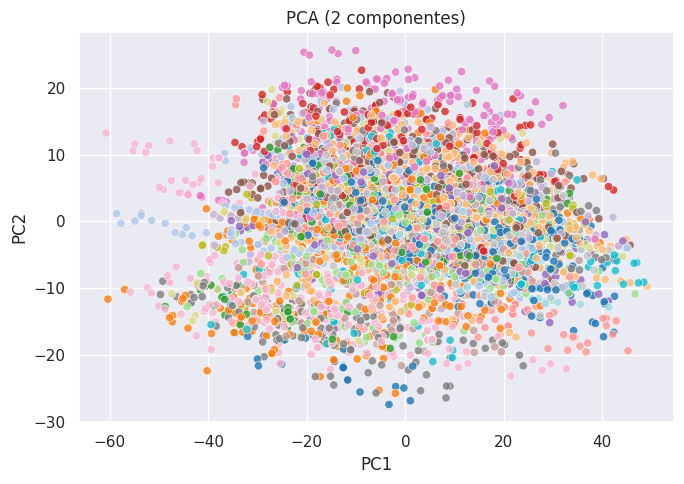

In [81]:
pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_scaled)

print(
    "PCA explained variance ratio:",
    pca.explained_variance_ratio_,
    "| acumulada:",
    pca.explained_variance_ratio_.sum()
)


pca_df = pd.DataFrame(Z_pca, columns=["PC1", "PC2"])
pca_df["label"] = y

sns.set_theme(style="darkgrid")

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="label",
    palette="tab20",
    alpha=0.8,
    legend=False
)
plt.title("PCA (2 componentes)")
plt.tight_layout()
plt.show()

#### Visualización de 3 Componentes

In [82]:
from mpl_toolkits.mplot3d import Axes3D

PCA explained variance ratio: [0.36980826 0.08758259 0.06827545] | acumulada: 0.5256662915452278


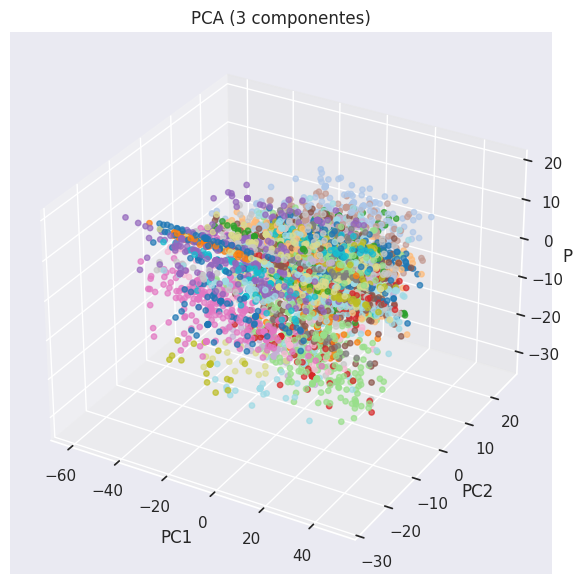

In [83]:
pca_3d = PCA(n_components=3, random_state=42)
Z_pca_3d = pca_3d.fit_transform(X_scaled)

print(
    "PCA explained variance ratio:",
    pca_3d.explained_variance_ratio_,
    "| acumulada:",
    pca_3d.explained_variance_ratio_.sum()
)


fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    Z_pca_3d[:,0],
    Z_pca_3d[:,1],
    Z_pca_3d[:,2],
    c=y.astype(int),
    cmap="tab20",
    alpha=0.7,
    s=15
)

ax.set_title("PCA (3 componentes)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.tight_layout()
plt.show()

### t-SNE

#### Visualización de 2 Componentes

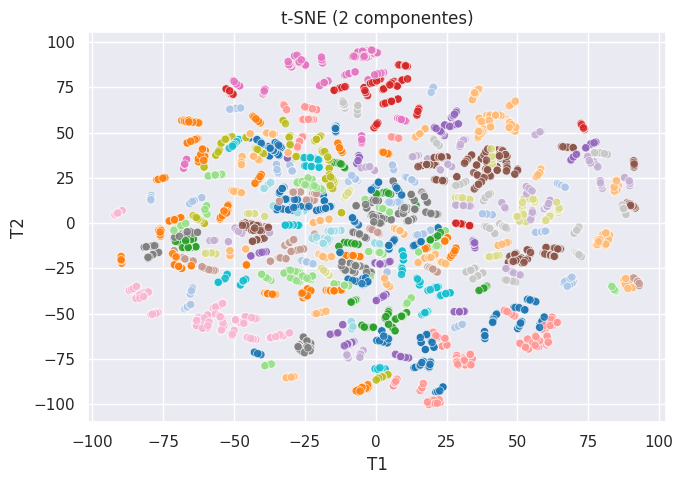

In [84]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

Z_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(Z_tsne, columns=["T1", "T2"])
tsne_df["label"] = y

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=tsne_df,
    x="T1",
    y="T2",
    hue="label",
    palette="tab20",
    alpha=0.8,
    legend=False
)
plt.title("t-SNE (2 componentes)")
plt.tight_layout()
plt.show()

### UMAP

### Visualización de 2 Componentes

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


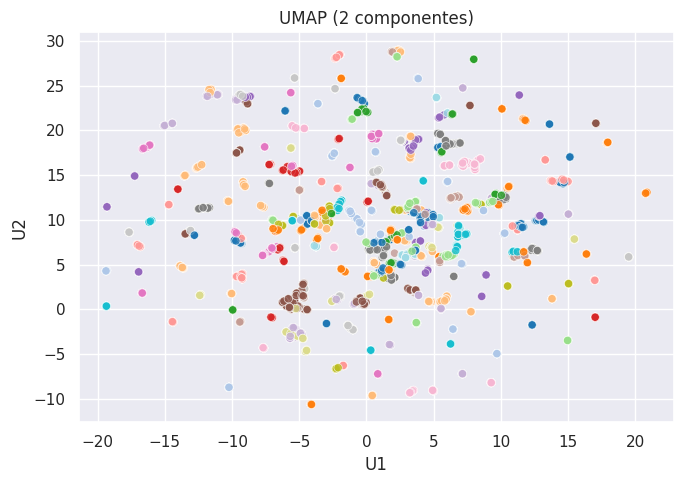

In [85]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

Z_umap = reducer.fit_transform(X_scaled)

umap_df = pd.DataFrame(Z_umap, columns=["U1", "U2"])
umap_df["label"] = y

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=umap_df,
    x="U1",
    y="U2",
    hue="label",
    palette="tab20",
    alpha=0.8,
    legend=False
)
plt.title("UMAP (2 componentes)")
plt.tight_layout()
plt.show()


#### Visualizacón de 3 Componentes

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


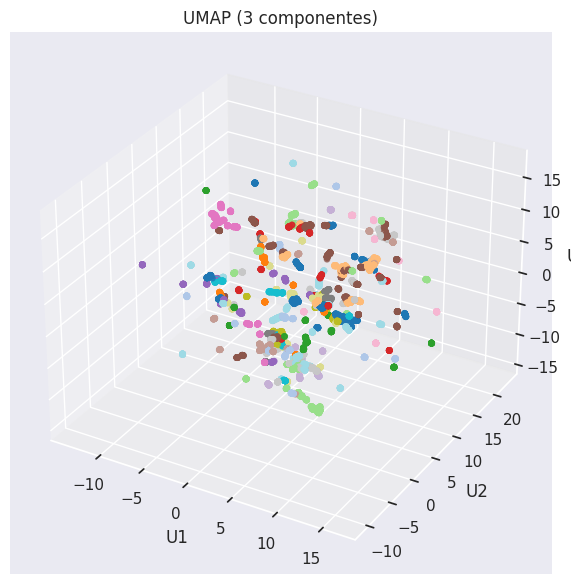

In [86]:
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)
Z_umap_3d = umap_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    Z_umap_3d[:,0],
    Z_umap_3d[:,1],
    Z_umap_3d[:,2],
    c=y.astype(int),
    cmap="tab20",
    alpha=0.7,
    s=15
)

ax.set_title("UMAP (3 componentes)")
ax.set_xlabel("U1")
ax.set_ylabel("U2")
ax.set_zlabel("U3")
plt.tight_layout()
plt.show()

| Método | Tipo      | Qué preserva    | Resultado        |
| ------ | --------- | --------------- | ---------------- |
| PCA    | Lineal    | Varianza global | Baseline         |
| t-SNE  | No lineal | Vecindad local  | Excelente visual |
| UMAP   | No lineal | Local + global  | Mejor balance    |


> Los datos fueron estandarizados previo a la aplicación de los métodos de reducción de dimensionalidad, dado que los algoritmos utilizados se basan en medidas de distancia. PCA se utilizó como método lineal de referencia, mostrando una separación limitada entre las clases. En contraste, t-SNE y UMAP, al capturar relaciones no lineales, lograron una mejor preservación de la similitud entre imágenes. En particular, UMAP presentó un equilibrio adecuado entre separación de clases y estructura global, resultando el método más adecuado para este problema.

### Letras Similares

In [87]:
letras_similares = ["0", "1", "2", "3"]  # ajusta según tu dataset
mask = y.isin(letras_similares)

X_sub = X_scaled[mask]
y_sub = y[mask]

In [88]:
umap_sub = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
)

Z_umap_sub = umap_sub.fit_transform(X_sub)

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [89]:
umap_tuned = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.05,
    metric="cosine",
    random_state=42
)

Z_umap_tuned = umap_tuned.fit_transform(X_sub)

df_umap_sub = pd.DataFrame(Z_umap_tuned, columns=["U1", "U2"])
df_umap_sub["label"] = y_sub.values

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


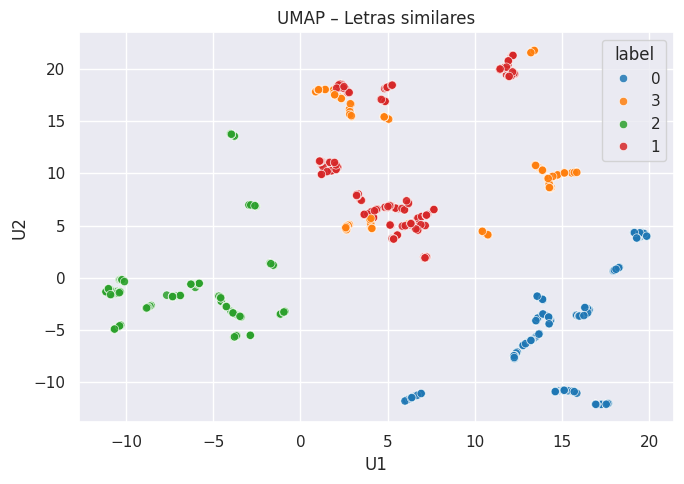

In [90]:
# df_umap_sub = pd.DataFrame(Z_umap_sub, columns=["U1", "U2"])
# df_umap_sub["label"] = y_sub.values

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_umap_sub,
    x="U1",
    y="U2",
    hue="label",
    palette="tab10",
    alpha=0.85
)

plt.title("UMAP – Letras similares")
plt.tight_layout()
plt.show()


In [91]:
def plot_n_umap(n_neighbors: int, min_dist: float):
    umap_tuned = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=42
    )
    
    Z_umap_tuned = umap_tuned.fit_transform(X_sub)
    
    df_umap_sub = pd.DataFrame(Z_umap_tuned, columns=["U1", "U2"])
    df_umap_sub["label"] = y_sub.values
    
    # df_umap_sub = pd.DataFrame(Z_umap_sub, columns=["U1", "U2"])
    # df_umap_sub["label"] = y_sub.values
    
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=df_umap_sub,
        x="U1",
        y="U2",
        hue="label",
        palette="tab10",
        alpha=0.85
    )
    
    plt.title("UMAP – Letras similares")
    plt.tight_layout()
    plt.show()


# for n_neighbors between 10 and 30 step by 5
# for min_dist in {0, 0.05, 0.1]

In [92]:
def plot_umap_grid(neighbors_list, min_dist_list, X_sub, y_sub, metric="cosine", random_state=42):
    sns.set_theme(style="darkgrid")

    n_rows = len(neighbors_list)
    n_cols = len(min_dist_list)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), sharex=False, sharey=False)

    # Si solo hay 1 fila o 1 columna, axes no es matriz; lo normalizamos
    if n_rows == 1 and n_cols == 1:
        axes = [[axes]]
    elif n_rows == 1:
        axes = [axes]
    elif n_cols == 1:
        axes = [[ax] for ax in axes]

    for i, n_neighbors in enumerate(neighbors_list):
        for j, min_dist in enumerate(min_dist_list):
            reducer = umap.UMAP(
                n_components=2,
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                metric=metric,
                random_state=random_state
            )

            Z = reducer.fit_transform(X_sub)

            ax = axes[i][j]
            sns.scatterplot(
                x=Z[:, 0],
                y=Z[:, 1],
                hue=y_sub,
                palette="tab10",
                alpha=0.85,
                s=18,
                linewidth=0,
                ax=ax,
                legend=False  # para no repetir leyenda en cada subplot
            )

            ax.set_title(f"n_neighbors={n_neighbors}, min_dist={min_dist}")
            ax.set_xlabel("")
            ax.set_ylabel("")

    # Leyenda única (a la derecha)
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, title="label", bbox_to_anchor=(1.02, 0.5), loc="center left")

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting r

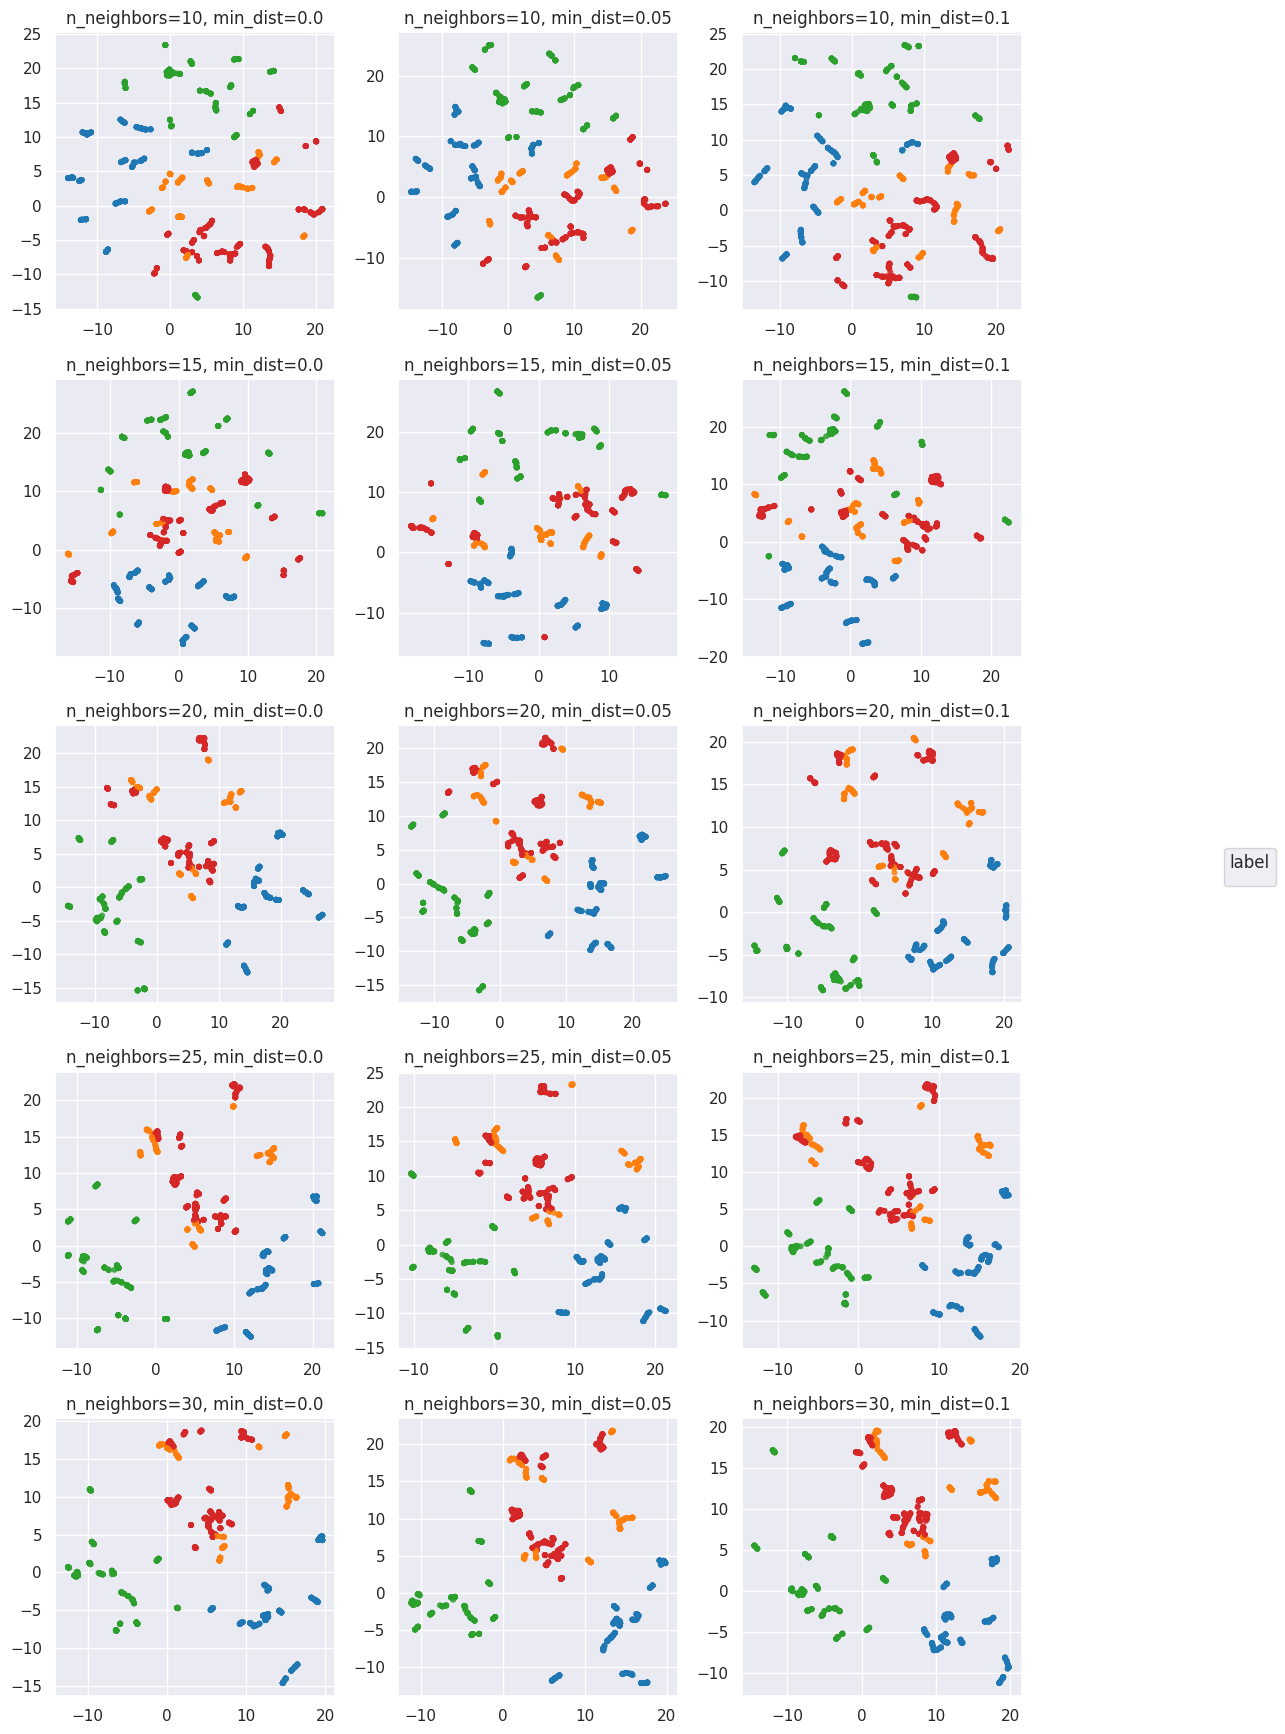

In [93]:
neighbors_list = list(range(10, 31, 5))  # 10, 15, 20, 25, 30
min_dist_list = [0.0, 0.05, 0.1]

plot_umap_grid(neighbors_list, min_dist_list, X_sub, y_sub)

| Objetivo          | Configuración                     |
| ----------------- | --------------------------------- |
| Máxima separación | `n_neighbors=20, min_dist=0.0`    |
| Más continuidad   | `n_neighbors=30, min_dist=0.1`    |
| Visual limpia     | `n_neighbors=25, min_dist=0.05` ✅ |


/home/erick/Entorno/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


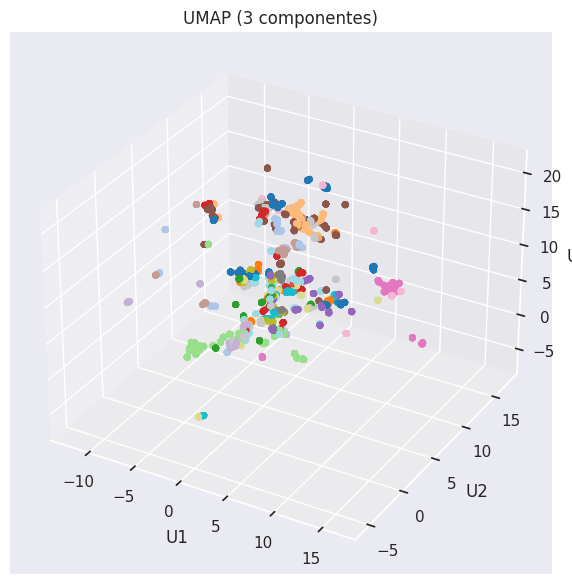

In [94]:
umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=25,
    min_dist=0.05,
    random_state=42
)
Z_umap_3d = umap_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    Z_umap_3d[:,0],
    Z_umap_3d[:,1],
    Z_umap_3d[:,2],
    c=y.astype(int),
    cmap="tab20",
    alpha=0.7,
    s=15
)

ax.set_title("UMAP (3 componentes)")
ax.set_xlabel("U1")
ax.set_ylabel("U2")
ax.set_zlabel("U3")
plt.tight_layout()
plt.show()

> Se exploró la representación de los datos en espacios bidimensionales y tridimensionales. Si bien el uso de tres componentes permite capturar mayor variabilidad, las representaciones bidimensionales resultaron suficientes para fines de visualización. Adicionalmente, se analizaron subconjuntos de letras visualmente similares, observándose que métodos no lineales como UMAP preservan de mejor manera la similitud entre gestos, en contraste con métodos lineales como PCA.

> A partir del análisis de sensibilidad de los parámetros de UMAP, se observó que valores intermedios del número de vecinos producen representaciones más estables y coherentes. En particular, la configuración con n_neighbors = 25 y min_dist = 0.05 permitió obtener clusters compactos y bien separados, preservando simultáneamente la similitud entre gestos visualmente relacionados. Por ello, esta configuración fue seleccionada como la más adecuada para la visualización del conjunto de datos.

## Conclusión

En este ejercicio se analizó un conjunto de datos compuesto por imágenes de lenguaje de señas representadas como vectores de intensidades de píxeles, con el objetivo de evaluar distintos métodos de reducción de dimensionalidad y su capacidad para preservar la similitud visual entre gestos. Dado que los datos corresponden a imágenes de alta dimensionalidad, se realizó previamente la estandarización de las variables para garantizar una aplicación adecuada de métodos basados en distancias.

Se aplicaron métodos lineales y no lineales de reducción de dimensionalidad. PCA se utilizó como método base, permitiendo una reducción eficiente de dimensiones, aunque con una capacidad limitada para separar gestos visualmente similares debido a su naturaleza lineal. En contraste, los métodos no lineales mostraron una mejor preservación de las relaciones locales entre imágenes. En particular, t-SNE y UMAP lograron agrupar de manera más coherente las letras con gestos similares, evidenciando estructuras no lineales presentes en los datos.

Mediante un análisis sistemático de sensibilidad de los parámetros de UMAP, se observó que configuraciones intermedias del número de vecinos y de la distancia mínima producen representaciones más estables y consistentes. La configuración con n_neighbors = 25 y min_dist = 0.05 permitió obtener clusters compactos y bien definidos, manteniendo cercanas las imágenes con gestos similares y separando aquellas con diferencias más marcadas. Por esta razón, UMAP resultó ser el método más adecuado para el objetivo del problema.

En conjunto, los resultados muestran que, para datos de tipo imagen, los métodos no lineales ofrecen ventajas significativas sobre los métodos lineales tradicionales cuando el interés principal es la preservación de la similitud visual. PCA cumple un rol importante como referencia comparativa, mientras que UMAP se posiciona como la herramienta más efectiva para la visualización y exploración de este tipo de datos.
